# Spectral Motion: Selective Motion Manipulation Using Spectral Total Variation of Optical Flow

This notebook reproduces the experiments reported in Chapters 4 and 5 of the dissertation. The workflow is

\[
\text{video frames}
\rightarrow
\text{optical flow}
\rightarrow
\text{Spectral TV decomposition}
\rightarrow
\text{regional spectral analysis}
\rightarrow
\text{motion editing}.
\]

The controlled experiment is evaluated with both exact synthetic flow and Horn--Schunck flow. Spectral-band selection uses the calibration pairs only, and the selected indices are then fixed for all held-out pairs. The controlled evaluation reports both retained mean directional motion and a complementary full-vector endpoint-change measure.

The LASIESTA section is a separate component-level case study on real estimated flow. Its calibration-selected components are frozen and evaluated on all three held-out transitions; no real-video spectral editing is performed.

All generated figures, tables, and videos are written to `spectral_motion_dissertation_outputs/`.


## 1. Experimental protocol

The controlled sequence contains two equal-sized objects moving horizontally at different speeds. Seven frames produce six pairwise flow fields:

- calibration: `0->1`, `1->2`;
- buffer: `2->3`;
- held-out evaluation: `3->4`, `4->5`, `5->6`.

Exact flow is used to isolate the Spectral TV stage from motion-estimation error. Horn--Schunck flow is estimated from the rendered RGB frames and is processed with the same spectral procedure. The Target and Distractor masks are used for regional measurement and calibration; they are not inputs to the Spectral TV decomposition.

The final experiment uses LASIESTA sequence `O_SU_02`. Persistent pedestrian labels define the measurement regions, while Horn--Schunck and Spectral TV operate only on the image-derived flow.


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import re
import shutil
import zipfile
import urllib.request
from dataclasses import dataclass
from pathlib import Path

import cv2
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from IPython.display import Video, display

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

OUTPUT_ROOT = Path('spectral_motion_dissertation_outputs')
FIG_DIR = OUTPUT_ROOT / 'figures'
TABLE_DIR = OUTPUT_ROOT / 'tables'
VIDEO_DIR = OUTPUT_ROOT / 'videos'
CACHE_DIR = OUTPUT_ROOT / 'cache'
for d in [OUTPUT_ROOT, FIG_DIR, TABLE_DIR, VIDEO_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Numerical settings
DT = 0.5
N_TV_STEPS = 42
TV_ITERS_MAIN = 250
RUN_REAL_WORLD_CASE_STUDY = True
CAPTURE_GOAL = 0.80
DISTRACTOR_LIMIT = 0.10

# Horn-Schunck settings. Alpha is calibrated below using only synthetic calibration pairs.
HS_ALPHA_CANDIDATES = [0.04, 0.06, 0.08, 0.10, 0.12, 0.16, 0.20]
HS_LEVELS = 3
HS_WARPS = 4
HS_ITERS_PER_WARP = 100

CALIBRATION_PAIRS = [0, 1]
BUFFER_PAIR = 2
HELDOUT_PAIRS = [3, 4, 5]
GAINS = [0.0, 1.0, 2.0]

print(f'PyTorch device: {DEVICE}')
print(f'Output directory: {OUTPUT_ROOT.resolve()}')

# Plot settings
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.titlepad': 6,
    'figure.titlesize': 14,
})


PyTorch device: cuda
Output directory: /content/spectral_motion_dissertation_outputs


## 2. Mathematical model

For a flow field $v(x,y)\in\mathbb{R}^2$, the vectorial total variation is

\[
J(v)=\sum_{x,y}\sqrt{\lVert D_x v(x,y)\rVert_2^2+\lVert D_y v(x,y)\rVert_2^2}.
\]

A TV gradient-flow scale space is approximated with implicit proximal steps

\[
u_{k+1}=\operatorname{prox}_{\Delta t J}(u_k),\qquad u_0=v.
\]

The integrated discrete spectral component is

\[
\Psi_k \approx \Delta t\,\phi(t_k)
= k\left(u_{k-1}-2u_k+u_{k+1}\right),
\qquad t_k=k\Delta t.
\]

This scaling is convenient because the components can be summed directly. With the finite-horizon residual

\[
r_T=u(T)-T\,u_t(T),
\]

the inverse reconstruction is

\[
v\approx \sum_k \Psi_k+r_T.
\]

For a selected component interval $B$, motion editing is

\[
v^{(g)}=v+(g-1)\sum_{k\in B}\Psi_k,
\]

where $g=0$ suppresses the selected band, $g=1$ leaves the flow unchanged, and $g=2$ amplifies it.

In [2]:
@dataclass
class ControlledSequence:
    frames: np.ndarray
    target_masks: list[np.ndarray]
    distractor_masks: list[np.ndarray]
    background: np.ndarray
    target_velocity: np.ndarray
    distractor_velocity: np.ndarray


def make_controlled_sequence(
    n_frames: int = 7,
    height: int = 72,
    width: int = 128,
    radius: int = 10,
    target_velocity=(3.0, 0.0),
    distractor_velocity=(1.0, 0.0),
) -> ControlledSequence:
    yy, xx = np.mgrid[:height, :width]
    checker = ((xx // 12 + yy // 12) % 2).astype(np.float32)
    bg_gray = 0.25 + 0.08 * checker + 0.03 * (xx / width)
    background = np.stack([bg_gray, bg_gray, bg_gray], axis=-1).astype(np.float32)

    frames, target_masks, distractor_masks = [], [], []
    target_start = np.array([22.0, 24.0])
    distractor_start = np.array([82.0, 48.0])
    vt = np.asarray(target_velocity, np.float32)
    vd = np.asarray(distractor_velocity, np.float32)

    for t in range(n_frames):
        target_center = target_start + t * vt
        distractor_center = distractor_start + t * vd

        mt = (xx - target_center[0]) ** 2 + (yy - target_center[1]) ** 2 <= radius ** 2
        md = (xx - distractor_center[0]) ** 2 + (yy - distractor_center[1]) ** 2 <= radius ** 2

        # Textures move with the objects and give Horn-Schunck useful image gradients.
        tx = xx - target_center[0]
        ty = yy - target_center[1]
        target_texture = 0.55 + 0.18 * np.sin(0.9 * tx) * np.cos(0.8 * ty)

        dx = xx - distractor_center[0]
        dy = yy - distractor_center[1]
        distractor_texture = 0.55 + 0.18 * (
            ((np.floor((dx + radius) / 3) + np.floor((dy + radius) / 3)) % 2) * 2 - 1
        )

        frame = background.copy()
        frame[mt, 0] = 0.15
        frame[mt, 1] = 0.45
        frame[mt, 2] = np.clip(target_texture[mt] + 0.25, 0, 1)

        frame[md, 0] = np.clip(distractor_texture[md] + 0.25, 0, 1)
        frame[md, 1] = 0.38
        frame[md, 2] = 0.12

        frames.append(np.clip(frame, 0, 1).astype(np.float32))
        target_masks.append(mt)
        distractor_masks.append(md)

    return ControlledSequence(
        frames=np.stack(frames),
        target_masks=target_masks,
        distractor_masks=distractor_masks,
        background=background,
        target_velocity=vt,
        distractor_velocity=vd,
    )


def exact_flow_from_masks(target_mask, distractor_mask, target_velocity, distractor_velocity):
    flow = np.zeros((*target_mask.shape, 2), np.float32)
    flow[target_mask] = np.asarray(target_velocity, np.float32)
    flow[distractor_mask] = np.asarray(distractor_velocity, np.float32)
    return flow

## 3. Horn-Schunck optical flow

A coarse-to-fine Horn-Schunck implementation is used. The pyramid and repeated warping allow the classical model to handle the three-pixel Target displacement more reliably than a single linearisation. The regularisation parameter $\alpha$ is selected using only the synthetic calibration pairs and their known exact flow.

In [3]:
def rgb_to_gray(rgb):
    return (0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]).astype(np.float32)


def horn_schunck_single(im1, im2, alpha=0.06, n_iter=100):
    im1 = rgb_to_gray(im1) if im1.ndim == 3 else im1.astype(np.float32)
    im2 = rgb_to_gray(im2) if im2.ndim == 3 else im2.astype(np.float32)

    kx = np.array([[-1, 1], [-1, 1]], np.float32) * 0.25
    ky = np.array([[-1, -1], [1, 1]], np.float32) * 0.25
    kt = np.ones((2, 2), np.float32) * 0.25

    ix = cv2.filter2D(im1, -1, kx, borderType=cv2.BORDER_REFLECT) + cv2.filter2D(im2, -1, kx, borderType=cv2.BORDER_REFLECT)
    iy = cv2.filter2D(im1, -1, ky, borderType=cv2.BORDER_REFLECT) + cv2.filter2D(im2, -1, ky, borderType=cv2.BORDER_REFLECT)
    it = cv2.filter2D(im2, -1, kt, borderType=cv2.BORDER_REFLECT) - cv2.filter2D(im1, -1, kt, borderType=cv2.BORDER_REFLECT)

    u = np.zeros_like(im1)
    v = np.zeros_like(im1)
    average_kernel = np.array(
        [[1/12, 1/6, 1/12], [1/6, 0, 1/6], [1/12, 1/6, 1/12]],
        np.float32,
    )
    denominator = alpha * alpha + ix * ix + iy * iy + 1e-12

    for _ in range(n_iter):
        u_bar = cv2.filter2D(u, -1, average_kernel, borderType=cv2.BORDER_REFLECT)
        v_bar = cv2.filter2D(v, -1, average_kernel, borderType=cv2.BORDER_REFLECT)
        correction = (ix * u_bar + iy * v_bar + it) / denominator
        u = u_bar - ix * correction
        v = v_bar - iy * correction

    return np.stack([u, v], axis=-1)


def warp_second_image_to_first(image, flow):
    h, w = image.shape[:2]
    yy, xx = np.mgrid[:h, :w].astype(np.float32)
    map_x = xx + flow[..., 0].astype(np.float32)
    map_y = yy + flow[..., 1].astype(np.float32)
    return cv2.remap(image, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT101)


def resize_flow(flow, new_shape):
    new_h, new_w = map(int, new_shape)
    old_h, old_w = flow.shape[:2]
    resized = cv2.resize(flow, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    resized[..., 0] *= new_w / old_w
    resized[..., 1] *= new_h / old_h
    return resized


def horn_schunck_pyramid(im1, im2, alpha=0.06, levels=3, warps=4, iters_per_warp=100):
    g1 = rgb_to_gray(im1) if im1.ndim == 3 else im1.astype(np.float32)
    g2 = rgb_to_gray(im2) if im2.ndim == 3 else im2.astype(np.float32)

    pyramid1, pyramid2 = [g1], [g2]
    for _ in range(1, levels):
        pyramid1.append(cv2.pyrDown(pyramid1[-1]))
        pyramid2.append(cv2.pyrDown(pyramid2[-1]))

    flow = np.zeros((*pyramid1[-1].shape, 2), np.float32)
    for level in range(levels - 1, -1, -1):
        a, b = pyramid1[level], pyramid2[level]
        if flow.shape[:2] != a.shape:
            flow = resize_flow(flow, a.shape)
        for _ in range(warps):
            warped_b = warp_second_image_to_first(b, flow)
            increment = horn_schunck_single(a, warped_b, alpha=alpha, n_iter=iters_per_warp)
            flow += increment
    return flow


def endpoint_error(flow, reference, mask=None):
    error = np.linalg.norm(flow - reference, axis=-1)
    return float(error[mask].mean() if mask is not None else error.mean())

## 4. Vectorial TV proximal solver and spectral decomposition

The TV proximal problems are solved with a first-order primal-dual method. The implementation uses PyTorch tensors and automatically runs on CUDA when available. The dual projection is coupled over the two flow channels, giving vectorial rather than channel-by-channel TV.

In [4]:
def torch_gradient(u):
    gx = torch.zeros_like(u)
    gy = torch.zeros_like(u)
    gx[:, :-1, :] = u[:, 1:, :] - u[:, :-1, :]
    gy[:-1, :, :] = u[1:, :, :] - u[:-1, :, :]
    return torch.stack([gx, gy], dim=-1)


def torch_divergence(p):
    px, py = p[..., 0], p[..., 1]
    out = torch.zeros_like(px)

    if px.shape[1] > 1:
        out[:, 0, :] += px[:, 0, :]
        if px.shape[1] > 2:
            out[:, 1:-1, :] += px[:, 1:-1, :] - px[:, :-2, :]
        out[:, -1, :] += -px[:, -2, :]

    if py.shape[0] > 1:
        out[0, :, :] += py[0, :, :]
        if py.shape[0] > 2:
            out[1:-1, :, :] += py[1:-1, :, :] - py[:-2, :, :]
        out[-1, :, :] += -py[-2, :, :]

    return out


def tv_prox_vectorial_torch(f, lam, n_iter=250, tau=0.24, sigma=0.24):
    u = f.clone()
    u_bar = u.clone()
    p = torch.zeros((*f.shape, 2), dtype=f.dtype, device=f.device)

    for _ in range(n_iter):
        p = p + sigma * torch_gradient(u_bar)
        norm = torch.sqrt(torch.sum(p * p, dim=(-2, -1), keepdim=True) + 1e-12)
        p = p / torch.maximum(torch.ones_like(norm), norm / max(float(lam), 1e-8))

        u_old = u
        u = (u + tau * torch_divergence(p) + tau * f) / (1.0 + tau)
        u_bar = u + (u - u_old)

    return u


def spectral_cache_key(flow, dt, n_steps, tv_iters):
    h = hashlib.sha1()
    h.update(np.asarray(flow, np.float32).tobytes())
    h.update(f'{dt}_{n_steps}_{tv_iters}'.encode())
    return h.hexdigest()[:16]


def tv_spectral_decomposition(flow, dt=0.5, n_steps=42, tv_iters=250, use_cache=True):
    key = spectral_cache_key(flow, dt, n_steps, tv_iters)
    cache_file = CACHE_DIR / f'spectral_{key}.npz'
    if use_cache and cache_file.exists():
        data = np.load(cache_file)
        return {
            'components': data['components'],
            'residual': data['residual'],
            'reconstruction_error': float(data['reconstruction_error']),
        }

    f = torch.as_tensor(flow, dtype=torch.float32, device=DEVICE)
    states = [f.clone()]
    u = f.clone()

    for _ in range(n_steps):
        u = tv_prox_vectorial_torch(u, lam=dt, n_iter=tv_iters)
        states.append(u.clone())

    states = torch.stack(states, dim=0)
    components = torch.stack([
        k * (states[k - 1] - 2.0 * states[k] + states[k + 1])
        for k in range(1, n_steps)
    ], dim=0)

    T = n_steps * dt
    endpoint_derivative = (states[-1] - states[-2]) / dt
    residual = states[-1] - T * endpoint_derivative
    reconstruction = components.sum(dim=0) + residual
    reconstruction_error = torch.linalg.norm(reconstruction - f) / (torch.linalg.norm(f) + 1e-12)

    result = {
        'components': components.detach().cpu().numpy(),
        'residual': residual.detach().cpu().numpy(),
        'reconstruction_error': float(reconstruction_error.detach().cpu()),
    }
    np.savez_compressed(
        cache_file,
        components=result['components'],
        residual=result['residual'],
        reconstruction_error=np.array(result['reconstruction_error'], np.float32),
    )
    return result

## 5. Regional spectra, band selection, and editing metrics

For each ROI, every spectral component is reduced to a scalar by averaging its vector field over the ROI and projecting the result onto that ROI's original mean-flow direction. The resulting curve measures the directional motion contribution of each component.

The Target peak is the component with the largest positive Target contribution. Candidate bands must be contiguous and contain this peak.

In [5]:
def regional_mean_direction(flow, mask):
    mean_vector = flow[mask].mean(axis=0)
    speed = float(np.linalg.norm(mean_vector))
    direction = mean_vector / (speed + 1e-12)
    return mean_vector, direction, speed


def regional_component_profile(decomposition, flow, mask):
    _, direction, base_speed = regional_mean_direction(flow, mask)
    mean_component_vectors = decomposition['components'][:, mask].mean(axis=1)
    signed_contribution = mean_component_vectors @ direction
    return signed_contribution, base_speed, direction


def select_peak_centred_band(
    decompositions,
    flows,
    target_masks,
    distractor_masks,
    capture_goal=0.80,
    distractor_limit=0.10,
):
    target_profiles, distractor_profiles = [], []
    target_speeds, distractor_speeds = [], []

    for dec, flow, mt, md in zip(decompositions, flows, target_masks, distractor_masks):
        pt, st, _ = regional_component_profile(dec, flow, mt)
        pd_, sd, _ = regional_component_profile(dec, flow, md)
        target_profiles.append(pt)
        distractor_profiles.append(pd_)
        target_speeds.append(st)
        distractor_speeds.append(sd)

    target_profile = np.mean(target_profiles, axis=0)
    distractor_profile = np.mean(distractor_profiles, axis=0)
    target_speed = float(np.mean(target_speeds))
    distractor_speed = float(np.mean(distractor_speeds))

    peak = int(np.argmax(np.maximum(target_profile, 0.0)))
    candidates = []
    for left in range(len(target_profile)):
        for right in range(left, len(target_profile)):
            if not (left <= peak <= right):
                continue
            target_capture = float(target_profile[left:right + 1].sum() / (target_speed + 1e-12))
            distractor_change = float(abs(distractor_profile[left:right + 1].sum()) / (distractor_speed + 1e-12))
            candidates.append({
                'left': left,
                'right': right,
                'width': right - left + 1,
                'target_capture': target_capture,
                'distractor_change': distractor_change,
            })

    valid = [
        c for c in candidates
        if c['target_capture'] >= capture_goal and c['distractor_change'] <= distractor_limit
    ]
    if valid:
        selected = min(valid, key=lambda c: (c['width'], c['distractor_change'], -c['target_capture']))
        status = 'goal_met'
    else:
        feasible = [c for c in candidates if c['distractor_change'] <= distractor_limit]
        if feasible:
            selected = max(feasible, key=lambda c: c['target_capture'])
            status = 'best_feasible_below_capture_goal'
        else:
            selected = min(candidates, key=lambda c: c['distractor_change'])
            status = 'minimum_leakage_fallback'

    selected.update({
        'peak': peak,
        'target_profile': target_profile,
        'distractor_profile': distractor_profile,
        'status': status,
        'calibration_target_speed': target_speed,
        'calibration_distractor_speed': distractor_speed,
    })
    return selected


def selected_band_field(decomposition, band):
    return decomposition['components'][band['left']:band['right'] + 1].sum(axis=0)


def edit_flow(flow, decomposition, band, gain):
    band_field = selected_band_field(decomposition, band)
    return flow + (gain - 1.0) * band_field, band_field


def retained_directional_motion(original_flow, edited_flow, mask):
    """Retained mean motion along the original mean direction.

    This is intentionally a directional regional summary, not a complete
    vector-field preservation metric.
    """
    _, direction, base_speed = regional_mean_direction(original_flow, mask)
    edited_mean = edited_flow[mask].mean(axis=0)
    return float((edited_mean @ direction) / (base_speed + 1e-12))


def mean_endpoint_change(original_flow, edited_flow, mask):
    """Mean pointwise full-vector change in pixels/frame."""
    delta = edited_flow[mask] - original_flow[mask]
    return float(np.linalg.norm(delta, axis=-1).mean())


def mean_original_vector_magnitude(original_flow, mask):
    """Mean pointwise original flow magnitude in pixels/frame."""
    return float(np.linalg.norm(original_flow[mask], axis=-1).mean())


def relative_endpoint_change(original_flow, edited_flow, mask):
    """Mean endpoint change relative to mean original pointwise magnitude."""
    absolute_change = mean_endpoint_change(original_flow, edited_flow, mask)
    reference = mean_original_vector_magnitude(original_flow, mask)
    return float(absolute_change / (reference + 1e-12))


def controlled_background_mask(sequence, pair):
    """Background ROI at the source frame of a pairwise flow field."""
    return ~(sequence.target_masks[pair] | sequence.distractor_masks[pair])


def evaluate_heldout(method_name, flows, decompositions, band, sequence):
    rows = []
    for pair in HELDOUT_PAIRS:
        mt = sequence.target_masks[pair]
        md = sequence.distractor_masks[pair]
        mbg = controlled_background_mask(sequence, pair)

        for gain in GAINS:
            edited, _ = edit_flow(flows[pair], decompositions[pair], band, gain)
            rows.append({
                'method': method_name,
                'pair': f'{pair}->{pair + 1}',
                'gain': gain,

                # Primary directional summaries.
                'target_retained': retained_directional_motion(flows[pair], edited, mt),
                'distractor_retained': retained_directional_motion(flows[pair], edited, md),

                # Complementary full-vector endpoint changes.
                'target_endpoint_change_px_per_frame': mean_endpoint_change(flows[pair], edited, mt),
                'target_relative_endpoint_change': relative_endpoint_change(flows[pair], edited, mt),
                'distractor_endpoint_change_px_per_frame': mean_endpoint_change(flows[pair], edited, md),
                'distractor_relative_endpoint_change': relative_endpoint_change(flows[pair], edited, md),
                'background_endpoint_change_px_per_frame': mean_endpoint_change(flows[pair], edited, mbg),
                'background_original_mean_magnitude_px_per_frame': mean_original_vector_magnitude(flows[pair], mbg),
            })
    return pd.DataFrame(rows)


In [6]:
def flow_magnitude(flow):
    return np.linalg.norm(flow, axis=-1)


def quiver_region_means(ax, flow, target_mask, distractor_mask, scale=1.0, show_original=None):
    def centre(mask):
        ys, xs = np.nonzero(mask)
        return np.array([xs.mean(), ys.mean()])

    for mask, colour, name in [
        (target_mask, '#f5a000', 'Target'),
        (distractor_mask, '#00a6c8', 'Distractor'),
    ]:
        c = centre(mask)
        mean = flow[mask].mean(axis=0)
        if show_original is not None:
            original_mean = show_original[mask].mean(axis=0)
            ax.arrow(c[0], c[1], original_mean[0] * scale, original_mean[1] * scale,
                     color='0.75', width=0.10, head_width=1.3, length_includes_head=True, zorder=5)
        ax.arrow(c[0], c[1], mean[0] * scale, mean[1] * scale,
                 color=colour, width=0.14, head_width=1.7, length_includes_head=True, zorder=6)


def contour_masks(ax, target_mask, distractor_mask):
    ax.contour(target_mask.astype(float), levels=[0.5], colors=['#f5a000'], linewidths=1.7, linestyles='-')
    ax.contour(distractor_mask.astype(float), levels=[0.5], colors=['#00a6c8'], linewidths=1.7, linestyles='--')


# Saved figures contain panel labels and axis labels; numbering is handled in LaTeX.

def save_show(fig, path, dpi=180):
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


def plot_protocol():
    fig, ax = plt.subplots(figsize=(10.0, 2.3))
    xs = np.arange(6)
    colours = ['#f5a000', '#f5a000', '0.7', '#3478b9', '#3478b9', '#3478b9']
    ax.plot(xs, np.zeros_like(xs), color='0.45', lw=1.8)
    ax.scatter(xs, np.zeros_like(xs), s=150, c=colours, edgecolor='0.25', zorder=3)
    for i in range(6):
        ax.text(i, -0.16, f'{i}->{i+1}', ha='center', va='top', fontsize=9.5)
    ax.text(0.5, 0.14, 'calibration', ha='center', weight='bold', fontsize=10)
    ax.text(2, 0.14, 'buffer', ha='center', weight='bold', color='0.4', fontsize=10)
    ax.text(4, 0.14, 'held-out', ha='center', weight='bold', fontsize=10)
    ax.set_ylim(-0.32, 0.28)
    ax.axis('off')
    save_show(fig, FIG_DIR / 'figure_01_protocol.png')


def plot_spectral_story(method_name, band, heldout_flow, heldout_dec, target_mask, distractor_mask):
    components = np.arange(1, len(band['target_profile']) + 1)
    band_field = selected_band_field(heldout_dec, band)
    mag = flow_magnitude(band_field)

    fig = plt.figure(figsize=(16.2, 4.0))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.35, 1.0])
    fig.subplots_adjust(left=0.035, right=0.975, top=0.93, bottom=0.12, wspace=0.42)
    axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

    im0 = axes[0].imshow(flow_magnitude(heldout_flow), cmap='viridis')
    contour_masks(axes[0], target_mask, distractor_mask)
    quiver_region_means(axes[0], heldout_flow, target_mask, distractor_mask, scale=4.0)
    axes[0].set_title('(a) Held-out flow')
    axes[0].axis('off')
    cb0 = fig.colorbar(im0, ax=axes[0], fraction=0.032, pad=0.05)
    cb0.set_label('Flow magnitude (pixels/frame)')

    axes[1].plot(components, band['target_profile'], lw=2.0, color='#f5a000', linestyle='-', marker='o', markevery=4, markersize=4, label='Target')
    axes[1].plot(components, band['distractor_profile'], lw=2.0, color='#00a6c8', linestyle='--', marker='s', markevery=4, markersize=4, label='Distractor')
    axes[1].axhline(0, color='0.6', lw=0.8)
    axes[1].axvspan(band['left'] + 1, band['right'] + 1, color='#d95f5f', alpha=0.16,
                    label=fr'$\psi_{{{band["left"]+1}}}$-$\psi_{{{band["right"]+1}}}$')
    axes[1].scatter([band['peak'] + 1], [band['target_profile'][band['peak']]], s=60,
                    color='#f5a000', edgecolor='black', zorder=5)
    axes[1].set_xlabel('Component index $k$')
    axes[1].set_ylabel('Directional response', labelpad=4)
    axes[1].set_title('(b) Calibration spectrum')
    axes[1].legend(fontsize=8.5, frameon=True, loc='upper right')
    axes[1].grid(alpha=0.25)

    vmax = max(float(np.percentile(mag, 99.5)), 1e-4)
    im2 = axes[2].imshow(mag, cmap='magma', vmin=0, vmax=vmax)
    contour_masks(axes[2], target_mask, distractor_mask)
    axes[2].set_title('(c) Held-out band magnitude')
    axes[2].axis('off')
    cb2 = fig.colorbar(im2, ax=axes[2], fraction=0.032, pad=0.03)
    cb2.set_label('Band magnitude (pixels/frame)')

    save_show(fig, FIG_DIR / ('figure_03_exact_spectral_story.png' if method_name.startswith('Exact') else 'figure_05_hs_spectral_story.png'))


def plot_flow_edit_triptych(method_name, flow, dec, band, target_mask, distractor_mask):
    edited_fields = [edit_flow(flow, dec, band, g)[0] for g in GAINS]
    vmax = max(np.percentile(flow_magnitude(f), 99.5) for f in edited_fields)

    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.0))
    fig.subplots_adjust(left=0.03, right=0.90, top=0.92, bottom=0.12, wspace=0.05)
    titles = ['(a) Suppress $g=0$', '(b) Original $g=1$', '(c) Amplify $g=2$']
    for ax, title, gain, edited in zip(axes, titles, GAINS, edited_fields):
        im = ax.imshow(flow_magnitude(edited), cmap='viridis', vmin=0, vmax=vmax)
        contour_masks(ax, target_mask, distractor_mask)
        quiver_region_means(ax, edited, target_mask, distractor_mask, scale=4.0)
        rt = retained_directional_motion(flow, edited, target_mask)
        rd = retained_directional_motion(flow, edited, distractor_mask)
        ax.text(0.02, 0.03, f'T: {100*rt:.1f}%\nD: {100*rd:.1f}%',
                transform=ax.transAxes, fontsize=8.5, va='bottom',
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='0.5'))
        ax.set_title(title)
        ax.axis('off')

    cax = fig.add_axes([0.915, 0.15, 0.010, 0.68])
    cb = fig.colorbar(im, cax=cax)
    cb.set_label('Flow magnitude (pixels/frame)')
    filename = 'figure_04_exact_flow_editing.png' if method_name.startswith('Exact') else 'figure_06_hs_flow_editing.png'
    save_show(fig, FIG_DIR / filename)



## 6. Controlled input sequence

The two objects have the same radius. Only their motion magnitude differs: the Target moves at 3 pixels per frame and the Distractor at 1 pixel per frame. This isolates the effect of speed from object size in the main experiment.

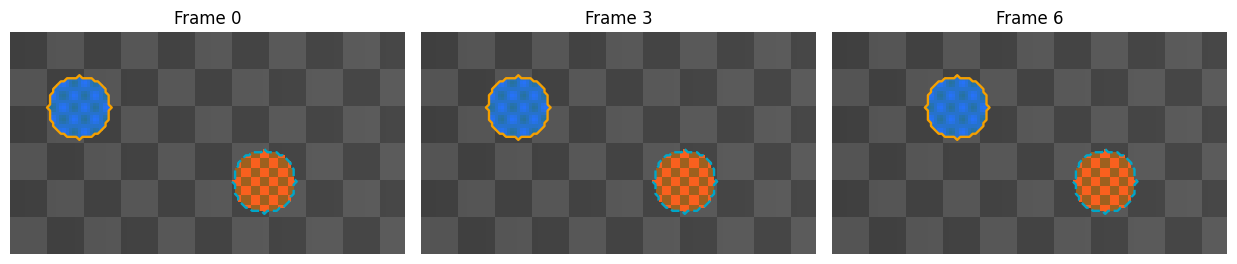

spectral_motion_dissertation_outputs/videos/video_00_controlled_input.mp4


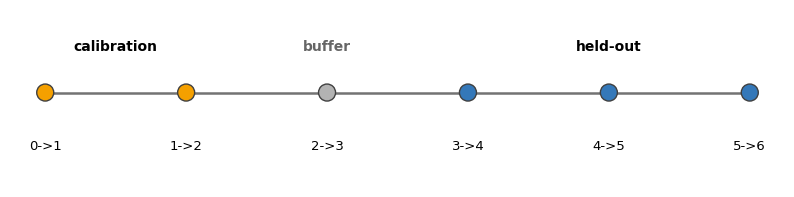

In [7]:
sequence = make_controlled_sequence()

# Show several frames so that the two prescribed motions are visible before
# any optical-flow or spectral analysis is introduced.
preview_indices = [0, 3, 6]
fig, axes = plt.subplots(1, len(preview_indices), figsize=(12.5, 3.8))
for ax, frame_idx in zip(axes, preview_indices):
    ax.imshow(sequence.frames[frame_idx])
    contour_masks(ax, sequence.target_masks[frame_idx], sequence.distractor_masks[frame_idx])
    ax.set_title(f'Frame {frame_idx}')
    ax.axis('off')
fig.tight_layout()
save_show(fig, FIG_DIR / 'figure_00_controlled_input.png')

input_video_path = VIDEO_DIR / 'video_00_controlled_input.mp4'
input_frames_u8 = [np.clip(frame * 255, 0, 255).astype(np.uint8) for frame in sequence.frames]
imageio.mimsave(
    input_video_path,
    input_frames_u8,
    fps=2,
    codec='libx264',
    quality=8,
    macro_block_size=None,
)
print(input_video_path)
display(Video(str(input_video_path), embed=True, width=640))

plot_protocol()


## 7. Horn-Schunck calibration

Horn-Schunck $\alpha$ is selected by endpoint error on the two synthetic calibration pairs only. The exact synthetic flow is available here specifically for parameter calibration and diagnostic evaluation; no held-out editing result is used to choose $\alpha$.

,alpha,calibration_EPE
0,0.04,0.420985
1,0.06,0.409765
2,0.08,0.421464
3,0.10,0.428487
4,0.12,0.429060
5,0.16,0.438423
6,0.20,0.467071


Selected Horn-Schunck alpha: 0.060


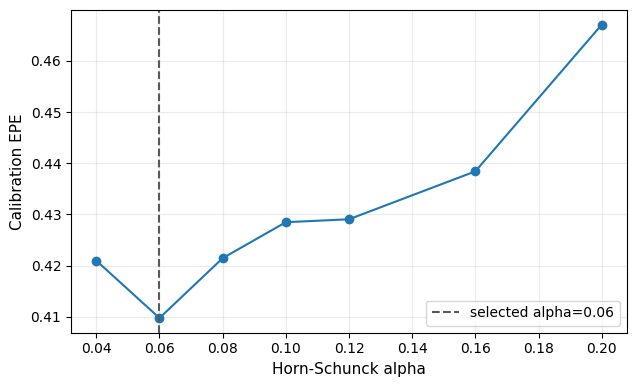

In [8]:
alpha_rows = []
for alpha in HS_ALPHA_CANDIDATES:
    errors = []
    for pair in CALIBRATION_PAIRS:
        gt = exact_flow_from_masks(
            sequence.target_masks[pair], sequence.distractor_masks[pair],
            sequence.target_velocity, sequence.distractor_velocity,
        )
        hs = horn_schunck_pyramid(
            sequence.frames[pair], sequence.frames[pair + 1],
            alpha=alpha, levels=HS_LEVELS, warps=HS_WARPS,
            iters_per_warp=HS_ITERS_PER_WARP,
        )
        moving_mask = sequence.target_masks[pair] | sequence.distractor_masks[pair]
        errors.append(endpoint_error(hs, gt, moving_mask))
    alpha_rows.append({'alpha': alpha, 'calibration_EPE': float(np.mean(errors))})

alpha_table = pd.DataFrame(alpha_rows)
HS_ALPHA = float(alpha_table.loc[alpha_table['calibration_EPE'].idxmin(), 'alpha'])
alpha_table.to_csv(TABLE_DIR / 'horn_schunck_alpha_calibration.csv', index=False)

display(alpha_table)
print(f'Selected Horn-Schunck alpha: {HS_ALPHA:.3f}')

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(alpha_table['alpha'], alpha_table['calibration_EPE'], marker='o')
ax.axvline(HS_ALPHA, color='0.35', linestyle='--', label=f'selected alpha={HS_ALPHA:.2f}')
ax.set_xlabel('Horn-Schunck alpha')
ax.set_ylabel('Calibration EPE')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
save_show(fig, FIG_DIR / 'figure_02_hs_alpha_calibration.png')

## 8. Compute exact-flow and Horn-Schunck spectral decompositions

Only calibration and held-out pairs are decomposed for the main experiment. Pair $2\to3$ remains unused as a buffer. Results are cached by a hash of the input flow and numerical settings, so repeated runs are much faster.

In [9]:
MAIN_PAIRS = CALIBRATION_PAIRS + HELDOUT_PAIRS

exact_flows, exact_decompositions = {}, {}
hs_flows, hs_decompositions = {}, {}

for pair in MAIN_PAIRS:
    exact_flow = exact_flow_from_masks(
        sequence.target_masks[pair], sequence.distractor_masks[pair],
        sequence.target_velocity, sequence.distractor_velocity,
    )
    exact_flows[pair] = exact_flow
    exact_decompositions[pair] = tv_spectral_decomposition(
        exact_flow, dt=DT, n_steps=N_TV_STEPS, tv_iters=TV_ITERS_MAIN,
    )

    hs_flow = horn_schunck_pyramid(
        sequence.frames[pair], sequence.frames[pair + 1],
        alpha=HS_ALPHA, levels=HS_LEVELS, warps=HS_WARPS,
        iters_per_warp=HS_ITERS_PER_WARP,
    )
    hs_flows[pair] = hs_flow
    hs_decompositions[pair] = tv_spectral_decomposition(
        hs_flow, dt=DT, n_steps=N_TV_STEPS, tv_iters=TV_ITERS_MAIN,
    )

reconstruction_table = pd.DataFrame([
    {
        'method': method,
        'pair': f'{pair}->{pair+1}',
        'relative_reconstruction_error': decompositions[pair]['reconstruction_error'],
    }
    for method, decompositions in [
        ('Exact flow', exact_decompositions),
        ('Horn-Schunck', hs_decompositions),
    ]
    for pair in MAIN_PAIRS
])
reconstruction_table.to_csv(TABLE_DIR / 'spectral_reconstruction_errors.csv', index=False)
display(reconstruction_table)

,method,pair,relative_reconstruction_error
0,Exact flow,0->1,2.792515e-07
1,Exact flow,1->2,2.818793e-07
2,Exact flow,3->4,2.780987e-07
3,Exact flow,4->5,2.540966e-07
4,Exact flow,5->6,2.449916e-07
5,Horn-Schunck,0->1,3.431790e-07
6,Horn-Schunck,1->2,3.384974e-07
7,Horn-Schunck,3->4,3.428952e-07
8,Horn-Schunck,4->5,2.861802e-07
9,Horn-Schunck,5->6,3.364277e-07


### Reconstruction check

The inverse spectral transform should reproduce the input flow up to numerical precision. This is an implementation check, not a motion-separation result. A small relative reconstruction error confirms that the component scaling and finite-horizon residual are internally consistent.

In [10]:
print(reconstruction_table.groupby('method')['relative_reconstruction_error'].agg(['mean', 'max']))

                      mean           max
method                                  
Exact flow    2.676635e-07  2.818793e-07
Horn-Schunck  3.294359e-07  3.431790e-07


## 9. Calibration-only band selection

The same predefined rule is applied separately to exact flow and Horn-Schunck flow. Component numbers are allowed to differ between methods because the input vector fields differ; the selection rule itself is unchanged.

In [11]:
exact_band = select_peak_centred_band(
    [exact_decompositions[i] for i in CALIBRATION_PAIRS],
    [exact_flows[i] for i in CALIBRATION_PAIRS],
    [sequence.target_masks[i] for i in CALIBRATION_PAIRS],
    [sequence.distractor_masks[i] for i in CALIBRATION_PAIRS],
    capture_goal=CAPTURE_GOAL,
    distractor_limit=DISTRACTOR_LIMIT,
)

hs_band = select_peak_centred_band(
    [hs_decompositions[i] for i in CALIBRATION_PAIRS],
    [hs_flows[i] for i in CALIBRATION_PAIRS],
    [sequence.target_masks[i] for i in CALIBRATION_PAIRS],
    [sequence.distractor_masks[i] for i in CALIBRATION_PAIRS],
    capture_goal=CAPTURE_GOAL,
    distractor_limit=DISTRACTOR_LIMIT,
)

band_table = pd.DataFrame([
    {
        'method': 'Exact flow',
        'target_peak': exact_band['peak'] + 1,
        'selected_band': f"psi{exact_band['left']+1}-psi{exact_band['right']+1}",
        'band_width': exact_band['width'],
        'predicted_target_capture': exact_band['target_capture'],
        'predicted_distractor_change': exact_band['distractor_change'],
        'status': exact_band['status'],
    },
    {
        'method': 'Horn-Schunck',
        'target_peak': hs_band['peak'] + 1,
        'selected_band': f"psi{hs_band['left']+1}-psi{hs_band['right']+1}",
        'band_width': hs_band['width'],
        'predicted_target_capture': hs_band['target_capture'],
        'predicted_distractor_change': hs_band['distractor_change'],
        'status': hs_band['status'],
    },
])
band_table.to_csv(TABLE_DIR / 'band_selection_summary.csv', index=False)
display(band_table)

,method,target_peak,selected_band,band_width,predicted_target_capture,predicted_distractor_change,status
0,Exact flow,26,psi25-psi29,5,0.816146,0.008172,goal_met
1,Horn-Schunck,31,psi27-psi37,11,0.803920,0.009787,goal_met


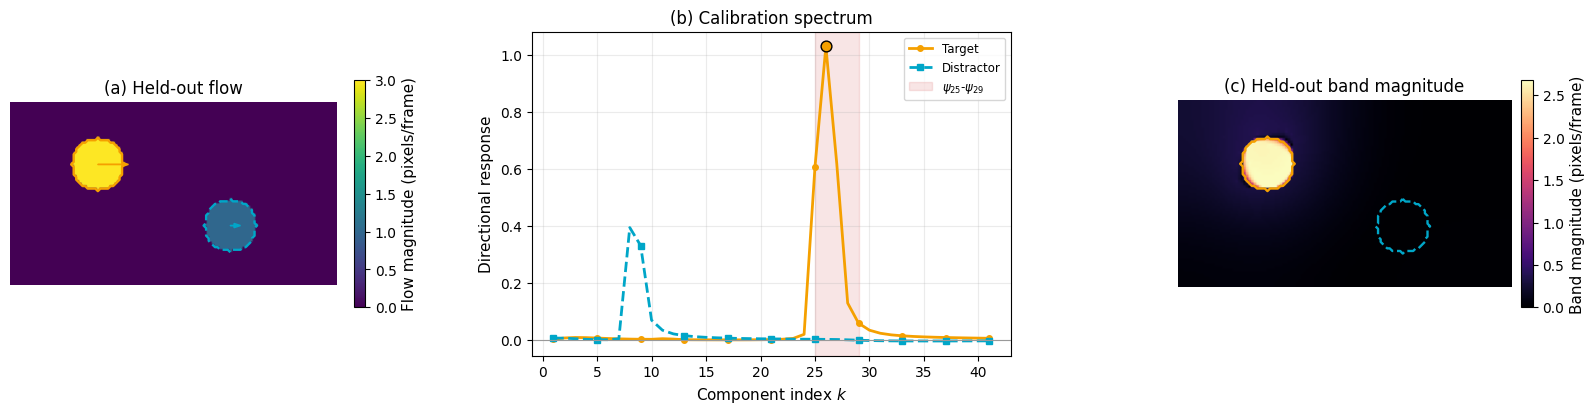

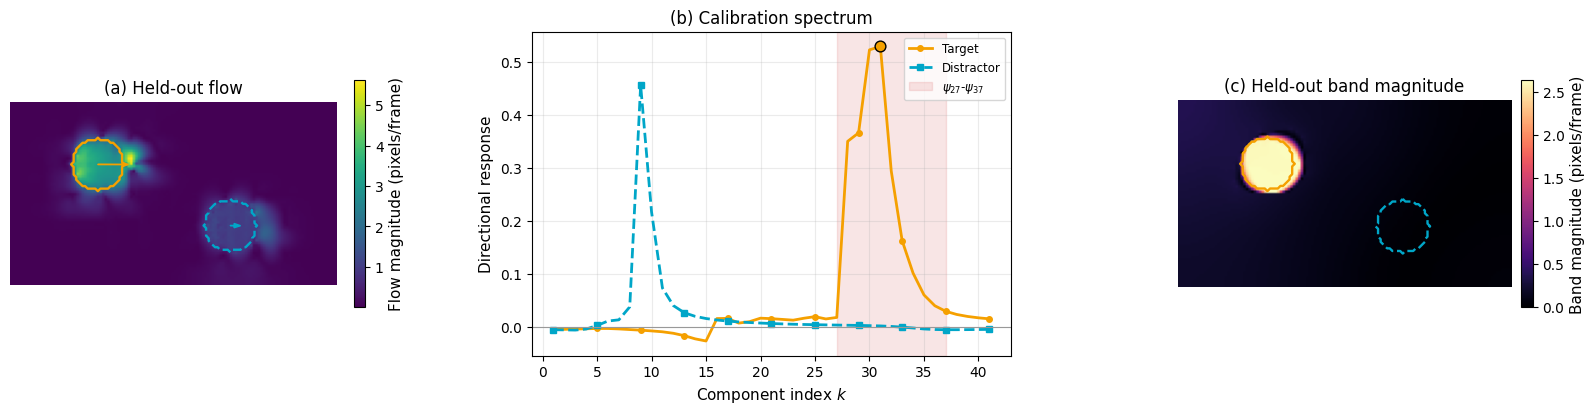

In [12]:
representative_pair = 4
plot_spectral_story(
    'Exact flow', exact_band,
    exact_flows[representative_pair], exact_decompositions[representative_pair],
    sequence.target_masks[representative_pair], sequence.distractor_masks[representative_pair],
)
plot_spectral_story(
    'Horn-Schunck', hs_band,
    hs_flows[representative_pair], hs_decompositions[representative_pair],
    sequence.target_masks[representative_pair], sequence.distractor_masks[representative_pair],
)

## 10. Held-out selective motion editing

The selected spectral interval is applied to the held-out frame pairs without re-selection.

For a selected band \(\mathcal{B}\), the edited flow is

\[
\mathbf{v}^{(g)}
=
\mathbf{v}
+
(g-1)
\sum_{k\in\mathcal{B}}\boldsymbol{\psi}_k,
\]

where:

- \(g=0\): suppress the selected spectral contribution;
- \(g=1\): retain the original optical flow;
- \(g=2\): amplify the selected spectral contribution.

The primary metric is **retained mean directional motion**. It measures the edited regional mean flow projected onto the region's original mean-motion direction; it does not by itself establish preservation of the complete vector field.

A complementary full-vector endpoint-change metric is therefore also reported:

\[
E_R^{(g)}
=
\frac{1}{|M_R|}
\sum_{(x,y)\in M_R}
\left\|
\mathbf{v}^{(g)}(x,y)-\mathbf{v}(x,y)
\right\|_2.
\]

For moving regions, the notebook additionally reports \(E_R^{(g)}\) relative to the original mean pointwise flow magnitude. For the exact-flow background, whose reference motion is zero, only the absolute endpoint change in pixels/frame is meaningful.


In [13]:
metrics = pd.concat([
    evaluate_heldout('Exact flow', exact_flows, exact_decompositions, exact_band, sequence),
    evaluate_heldout('Horn-Schunck', hs_flows, hs_decompositions, hs_band, sequence),
], ignore_index=True)
metrics.to_csv(TABLE_DIR / 'heldout_motion_editing.csv', index=False)

display(metrics)

# Compact per-pair table for the complementary preservation measures.
full_vector_columns = [
    'method',
    'pair',
    'gain',
    'target_relative_endpoint_change',
    'distractor_relative_endpoint_change',
    'background_endpoint_change_px_per_frame',
]
full_vector_metrics = metrics[full_vector_columns].copy()
full_vector_metrics.to_csv(TABLE_DIR / 'heldout_full_vector_endpoint_change.csv', index=False)
display(full_vector_metrics)


,method,pair,gain,target_retained,distractor_retained,target_endpoint_change_px_per_frame,target_relative_endpoint_change,distractor_endpoint_change_px_per_frame,distractor_relative_endpoint_change,background_endpoint_change_px_per_frame,background_original_mean_magnitude_px_per_frame
0,Exact flow,3->4,0.0,0.163831,0.996666,2.515116,0.838372,0.005846,0.005846,0.100451,0.000000
1,Exact flow,3->4,1.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Exact flow,3->4,2.0,1.836169,1.003334,2.515116,0.838372,0.005846,0.005846,0.100451,0.000000
3,Exact flow,4->5,0.0,0.161905,0.999121,2.520181,0.840060,0.005819,0.005819,0.100222,0.000000
4,Exact flow,4->5,1.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,Exact flow,4->5,2.0,1.838094,1.000879,2.520181,0.840060,0.005819,0.005819,0.100222,0.000000
6,Exact flow,5->6,0.0,0.161428,1.001920,2.521053,0.840351,0.006514,0.006514,0.099811,0.000000
7,Exact flow,5->6,1.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,Exact flow,5->6,2.0,1.838572,0.998080,2.521053,0.840351,0.006514,0.006514,0.099811,0.000000
9,Horn-Schunck,3->4,0.0,0.189618,1.025493,2.446092,0.805513,0.025852,0.025481,0.183793,0.155451


,method,pair,gain,target_relative_endpoint_change,distractor_relative_endpoint_change,background_endpoint_change_px_per_frame
0,Exact flow,3->4,0.0,0.838372,0.005846,0.100451
1,Exact flow,3->4,1.0,0.000000,0.000000,0.000000
2,Exact flow,3->4,2.0,0.838372,0.005846,0.100451
3,Exact flow,4->5,0.0,0.840060,0.005819,0.100222
4,Exact flow,4->5,1.0,0.000000,0.000000,0.000000
5,Exact flow,4->5,2.0,0.840060,0.005819,0.100222
6,Exact flow,5->6,0.0,0.840351,0.006514,0.099811
7,Exact flow,5->6,1.0,0.000000,0.000000,0.000000
8,Exact flow,5->6,2.0,0.840351,0.006514,0.099811
9,Horn-Schunck,3->4,0.0,0.805513,0.025481,0.183793


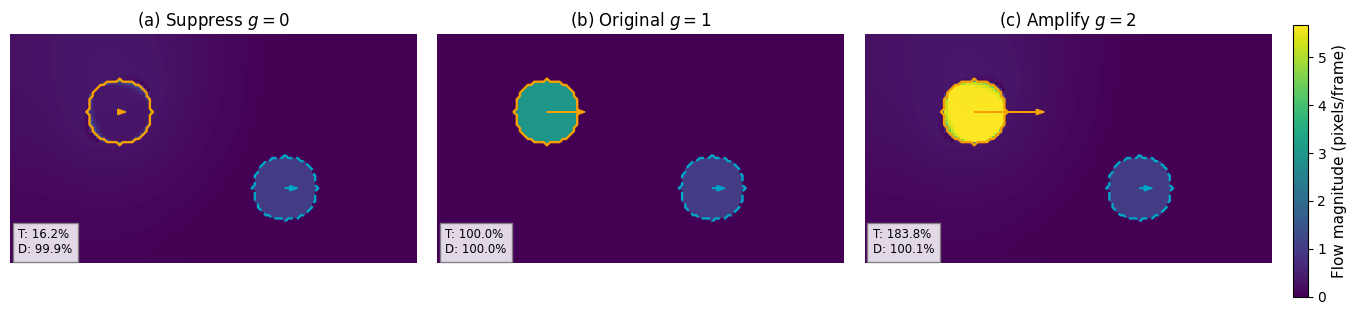

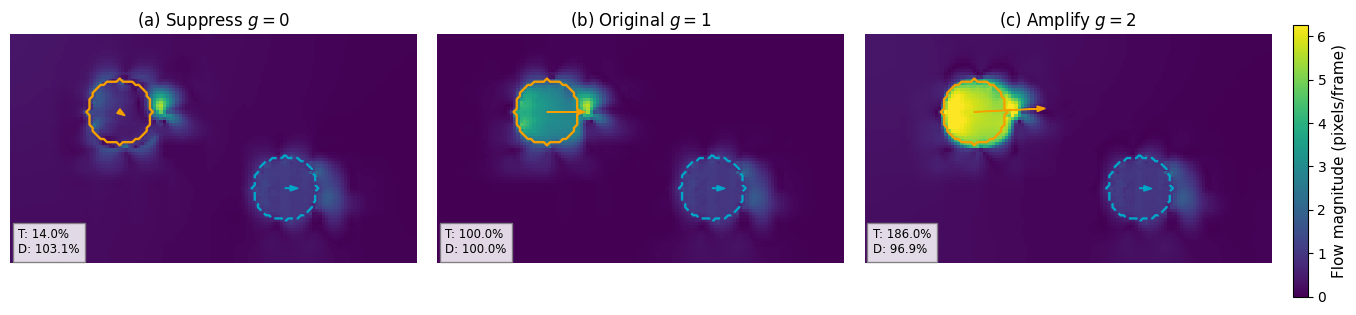

In [14]:
plot_flow_edit_triptych(
    'Exact flow', exact_flows[representative_pair], exact_decompositions[representative_pair], exact_band,
    sequence.target_masks[representative_pair], sequence.distractor_masks[representative_pair],
)
plot_flow_edit_triptych(
    'Horn-Schunck', hs_flows[representative_pair], hs_decompositions[representative_pair], hs_band,
    sequence.target_masks[representative_pair], sequence.distractor_masks[representative_pair],
)

## 11. Held-out flow sequence

Each column corresponds to one held-out frame pair,

\[
3\to4,\qquad 4\to5,\qquad 5\to6.
\]

Rows show suppression, the original flow, and amplification. Within each method, all panels use the same magnitude and arrow scales. The same sequence is also exported as an MP4.


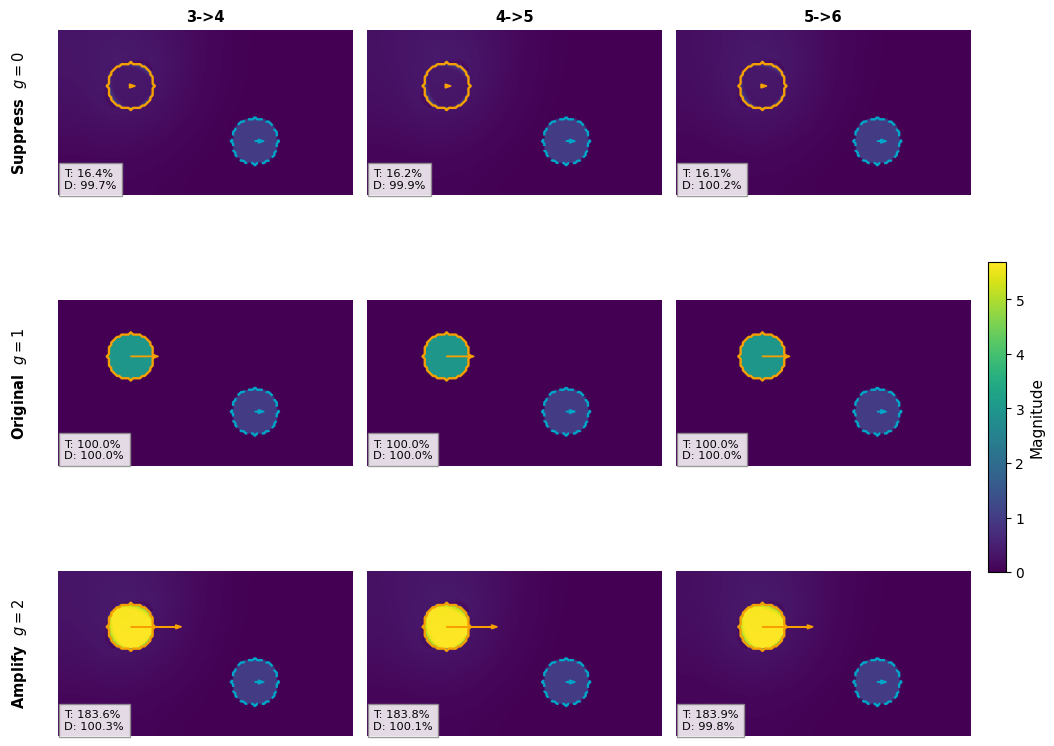

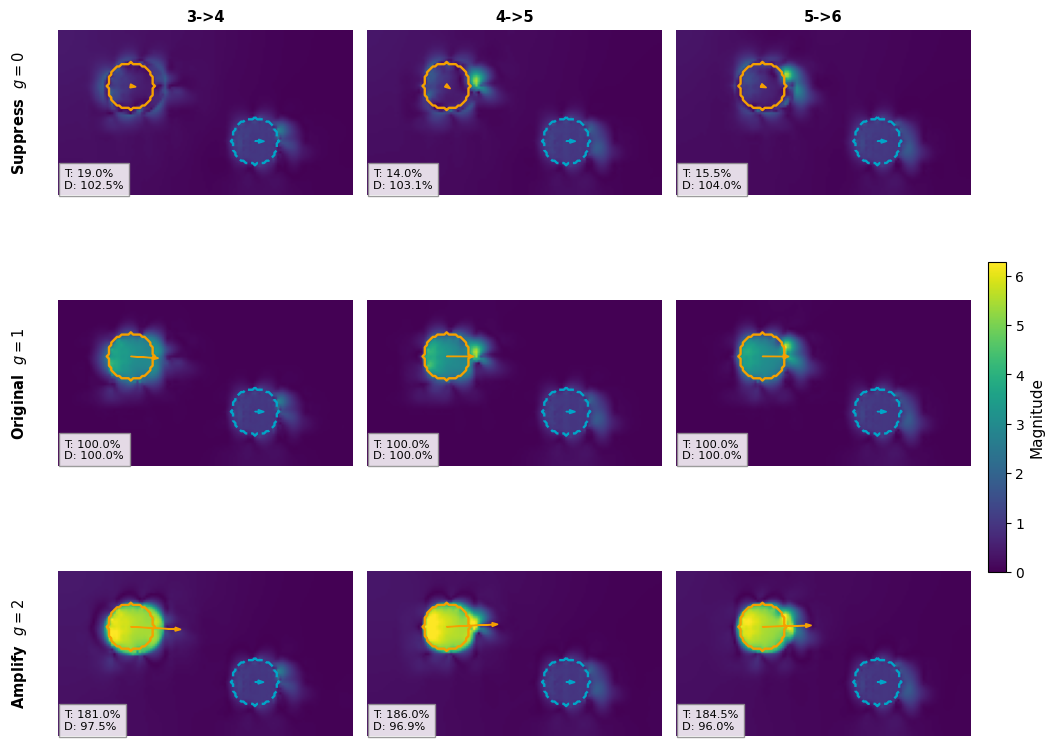

spectral_motion_dissertation_outputs/videos/video_01_exact_flow_control.mp4
spectral_motion_dissertation_outputs/videos/video_02_horn_schunck_flow_control.mp4


In [15]:
def edited_flow_for_pair(flows, decompositions, band, pair, gain):
    edited, _ = edit_flow(flows[pair], decompositions[pair], band, gain)
    return edited


def method_flow_vmax(flows, decompositions, band, pairs=HELDOUT_PAIRS):
    values = []
    for pair in pairs:
        for gain in GAINS:
            edited = edited_flow_for_pair(flows, decompositions, band, pair, gain)
            values.append(float(np.percentile(flow_magnitude(edited), 99.5)))
    return max(max(values), 1e-6)


def plot_heldout_flow_grid(flows, decompositions, band, sequence, path):
    row_labels = {0.0: 'Suppress  $g=0$', 1.0: 'Original  $g=1$', 2.0: 'Amplify  $g=2$'}
    vmax = method_flow_vmax(flows, decompositions, band)
    ncols = len(HELDOUT_PAIRS)
    fig, axes = plt.subplots(3, ncols, figsize=(3.8 * ncols, 8.6), squeeze=False)

    for row, gain in enumerate(GAINS):
        for col, pair in enumerate(HELDOUT_PAIRS):
            ax = axes[row, col]
            original = flows[pair]
            edited = edited_flow_for_pair(flows, decompositions, band, pair, gain)
            mt = sequence.target_masks[pair]
            md = sequence.distractor_masks[pair]
            im = ax.imshow(flow_magnitude(edited), cmap='viridis', vmin=0, vmax=vmax)
            contour_masks(ax, mt, md)
            quiver_region_means(ax, edited, mt, md, scale=4.0)
            rt = retained_directional_motion(original, edited, mt)
            rd = retained_directional_motion(original, edited, md)
            ax.text(0.02, 0.03, f'T: {100*rt:.1f}%\nD: {100*rd:.1f}%', transform=ax.transAxes,
                    fontsize=8.2, va='bottom', bbox=dict(facecolor='white', alpha=0.86, edgecolor='0.55'))
            if row == 0:
                ax.set_title(f'{pair}->{pair+1}', fontsize=10.5, weight='bold')
            if col == 0:
                ax.text(-0.10, 0.5, row_labels[gain], transform=ax.transAxes, rotation=90,
                        va='center', ha='right', fontsize=10.5, weight='bold')
            ax.axis('off')

    fig.subplots_adjust(left=0.08, right=0.88, top=0.96, bottom=0.04, wspace=0.05, hspace=0.08)
    cax = fig.add_axes([0.895, 0.28, 0.016, 0.36])
    cb = fig.colorbar(im, cax=cax)
    cb.set_label('Magnitude')
    save_show(fig, path, dpi=200)


def flow_video_frame(flows, decompositions, band, sequence, pair, vmax):
    fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.8))
    titles = ['Suppress  $g=0$', 'Original  $g=1$', 'Amplify  $g=2$']
    original = flows[pair]
    mt = sequence.target_masks[pair]
    md = sequence.distractor_masks[pair]
    for ax, title, gain in zip(axes, titles, GAINS):
        edited = edited_flow_for_pair(flows, decompositions, band, pair, gain)
        im = ax.imshow(flow_magnitude(edited), cmap='viridis', vmin=0, vmax=vmax)
        contour_masks(ax, mt, md)
        quiver_region_means(ax, edited, mt, md, scale=4.0)
        rt = retained_directional_motion(original, edited, mt)
        rd = retained_directional_motion(original, edited, md)
        ax.text(0.02, 0.03, f'T: {100*rt:.1f}%\nD: {100*rd:.1f}%', transform=ax.transAxes,
                fontsize=8, va='bottom', bbox=dict(facecolor='white', alpha=0.85, edgecolor='0.55'))
        ax.set_title(title, fontsize=10.5, weight='bold')
        ax.axis('off')
    fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.05, wspace=0.03)
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    rgb = rgba[..., :3].copy()
    plt.close(fig)
    return rgb

def write_heldout_flow_video(flows, decompositions, band, sequence, path, repeats=4, fps=4):
    vmax = method_flow_vmax(flows, decompositions, band)
    frames = []
    for pair in HELDOUT_PAIRS:
        image = flow_video_frame(
            flows, decompositions, band, sequence, pair, vmax
        )
        frames.extend([image] * repeats)
    imageio.mimsave(
        path,
        frames,
        fps=fps,
        codec='libx264',
        quality=8,
        macro_block_size=None,
    )
    return path


plot_heldout_flow_grid(
    exact_flows,
    exact_decompositions,
    exact_band,
    sequence,
    FIG_DIR / 'figure_07_exact_heldout_flow_sequence.png',
)

plot_heldout_flow_grid(
    hs_flows,
    hs_decompositions,
    hs_band,
    sequence,
    FIG_DIR / 'figure_08_horn_schunck_heldout_flow_sequence.png',
)

exact_flow_video = write_heldout_flow_video(
    exact_flows,
    exact_decompositions,
    exact_band,
    sequence,
    VIDEO_DIR / 'video_01_exact_flow_control.mp4',
)

hs_flow_video = write_heldout_flow_video(
    hs_flows,
    hs_decompositions,
    hs_band,
    sequence,
    VIDEO_DIR / 'video_02_horn_schunck_flow_control.mp4',
)

print(exact_flow_video)
print(hs_flow_video)

display(Video(str(exact_flow_video), embed=True, width=1000))
display(Video(str(hs_flow_video), embed=True, width=1000))

## 12. Flow-driven trajectories

For the controlled sequence, the edited regional mean flow is integrated from frame 3 to frame 6. The resulting positions are rendered with the original synthetic background, textures, colours, and object sizes.

The trajectory update is

\[
\mathbf p_{t+1}^{(g)} = \mathbf p_t^{(g)} + \overline{\mathbf v}_{t}^{(g)}.
\]

Yellow and cyan traces show the accumulated Target and Distractor paths. These figures visualise the motion implied by the edited flow; they do not reconstruct RGB frames from optical flow.


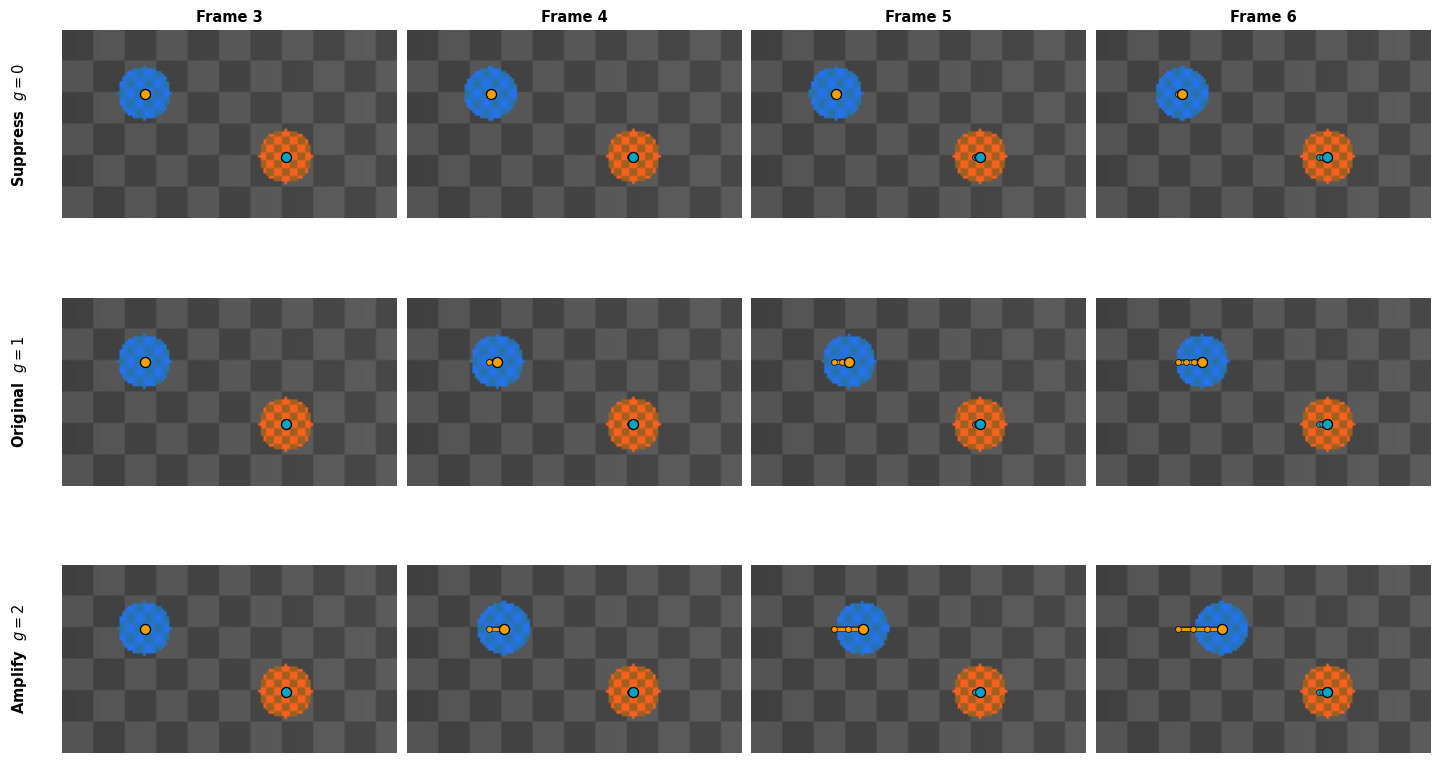

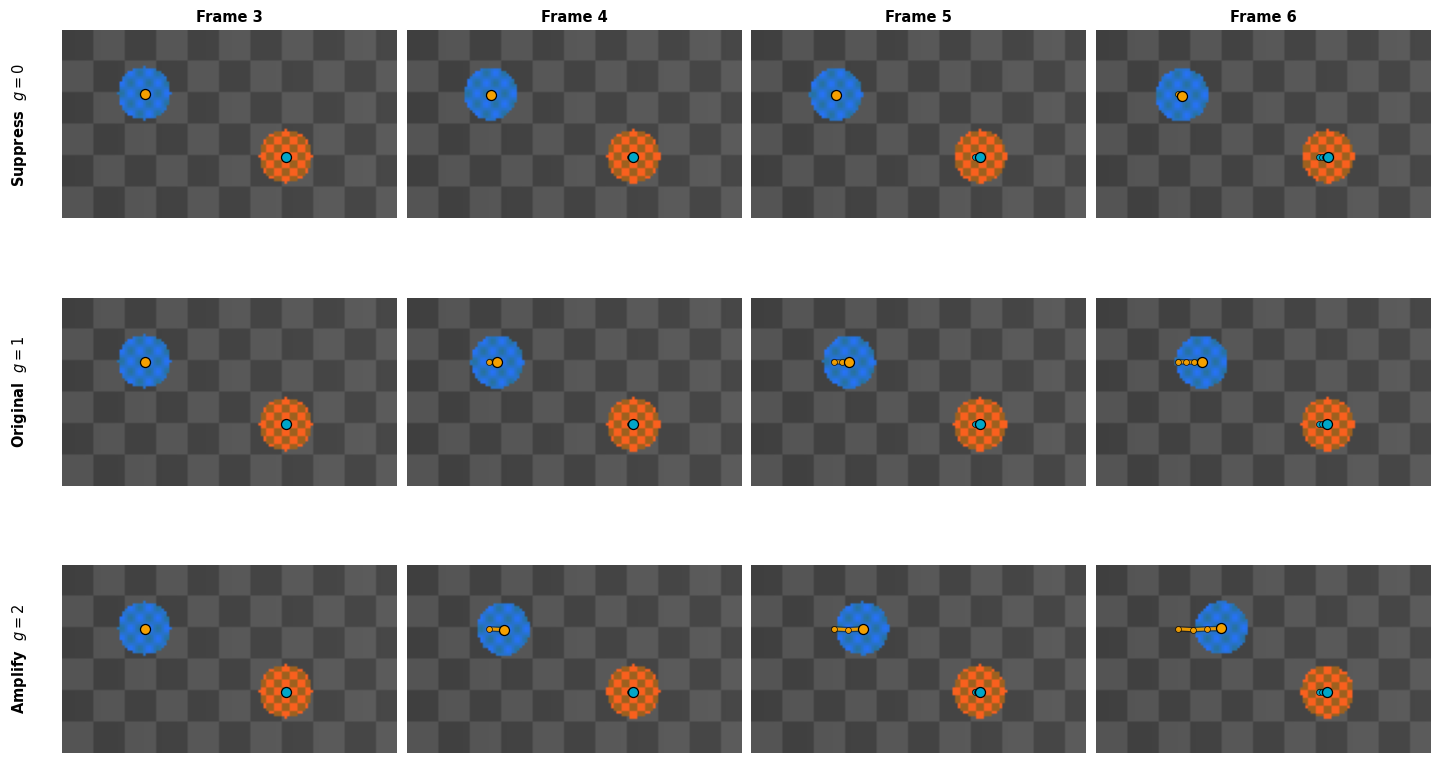

spectral_motion_dissertation_outputs/videos/video_03_exact_object_motion.mp4
spectral_motion_dissertation_outputs/videos/video_04_horn_schunck_object_motion.mp4


In [16]:
def mask_centroid(mask):
    yy, xx = np.nonzero(mask)
    return np.array([xx.mean(), yy.mean()], dtype=np.float32)


def mask_radius(mask):
    return float(np.sqrt(mask.sum() / np.pi))


def build_object_motion_paths(method_name, flows, decompositions, band, sequence):
    start_pair = HELDOUT_PAIRS[0]
    frame_indices = [start_pair] + [p + 1 for p in HELDOUT_PAIRS]

    target_start = mask_centroid(sequence.target_masks[start_pair])
    distractor_start = mask_centroid(sequence.distractor_masks[start_pair])
    target_radius = mask_radius(sequence.target_masks[start_pair])
    distractor_radius = mask_radius(sequence.distractor_masks[start_pair])

    paths = {}
    rows = []

    for gain in GAINS:
        target_positions = [target_start.copy()]
        distractor_positions = [distractor_start.copy()]
        target_velocities = []
        distractor_velocities = []
        pair_metrics = []

        for pair in HELDOUT_PAIRS:
            original = flows[pair]
            edited = edited_flow_for_pair(flows, decompositions, band, pair, gain)

            mt = sequence.target_masks[pair]
            md = sequence.distractor_masks[pair]

            vt = edited[mt].mean(axis=0).astype(np.float32)
            vd = edited[md].mean(axis=0).astype(np.float32)

            target_velocities.append(vt)
            distractor_velocities.append(vd)
            target_positions.append(target_positions[-1] + vt)
            distractor_positions.append(distractor_positions[-1] + vd)

            pair_metrics.append({
                'pair': pair,
                'target_retained': float(retained_directional_motion(original, edited, mt)),
                'distractor_retained': float(retained_directional_motion(original, edited, md)),
            })

        target_positions = np.asarray(target_positions, dtype=np.float32)
        distractor_positions = np.asarray(distractor_positions, dtype=np.float32)
        target_velocities = np.asarray(target_velocities, dtype=np.float32)
        distractor_velocities = np.asarray(distractor_velocities, dtype=np.float32)

        paths[gain] = {
            'frame_indices': frame_indices,
            'target_positions': target_positions,
            'distractor_positions': distractor_positions,
            'target_velocities': target_velocities,
            'distractor_velocities': distractor_velocities,
            'pair_metrics': pair_metrics,
            'target_radius': target_radius,
            'distractor_radius': distractor_radius,
        }

        for frame_idx, txy, dxy in zip(frame_indices, target_positions, distractor_positions):
            rows.append({
                'method': method_name,
                'gain': gain,
                'frame': frame_idx,
                'target_x': float(txy[0]),
                'target_y': float(txy[1]),
                'distractor_x': float(dxy[0]),
                'distractor_y': float(dxy[1]),
            })

    return paths, pd.DataFrame(rows)


def render_controlled_scene(sequence, target_center, distractor_center):
    """Re-render the controlled synthetic scene with the same appearance as the input sequence."""
    bg = sequence.background.copy()
    height, width = bg.shape[:2]
    yy, xx = np.mgrid[:height, :width]

    radius = mask_radius(sequence.target_masks[0])
    tc = np.asarray(target_center, dtype=np.float32)
    dc = np.asarray(distractor_center, dtype=np.float32)

    mt = (xx - tc[0]) ** 2 + (yy - tc[1]) ** 2 <= radius ** 2
    md = (xx - dc[0]) ** 2 + (yy - dc[1]) ** 2 <= radius ** 2

    tx = xx - tc[0]
    ty = yy - tc[1]
    target_texture = 0.55 + 0.18 * np.sin(0.9 * tx) * np.cos(0.8 * ty)

    dx = xx - dc[0]
    dy = yy - dc[1]
    distractor_texture = 0.55 + 0.18 * (
        ((np.floor((dx + radius) / 3) + np.floor((dy + radius) / 3)) % 2) * 2 - 1
    )

    frame = bg.copy()
    frame[mt, 0] = 0.15
    frame[mt, 1] = 0.45
    frame[mt, 2] = np.clip(target_texture[mt] + 0.25, 0, 1)

    frame[md, 0] = np.clip(distractor_texture[md] + 0.25, 0, 1)
    frame[md, 1] = 0.38
    frame[md, 2] = 0.12

    return np.clip(frame, 0, 1).astype(np.float32)


def rerender_object_motion_frame(sequence, path_data, gain, local_frame_idx):
    """Render one flow-driven frame using the original synthetic scene generator."""
    target_center = path_data[gain]['target_positions'][local_frame_idx]
    distractor_center = path_data[gain]['distractor_positions'][local_frame_idx]
    return render_controlled_scene(sequence, target_center, distractor_center)


def draw_trajectory_trail(ax, positions, current_idx, colour):
    """Overlay the accumulated edited path up to the current frame."""
    pts = np.asarray(positions[:current_idx + 1], dtype=np.float32)
    if len(pts) == 0:
        return

    # Dark underlay keeps the path visible on the textured background.
    if len(pts) > 1:
        ax.plot(
            pts[:, 0], pts[:, 1],
            color='black', linewidth=4.0, alpha=0.45,
            solid_capstyle='round', zorder=8,
        )
        ax.plot(
            pts[:, 0], pts[:, 1],
            color=colour, linewidth=2.2, alpha=0.95,
            solid_capstyle='round', zorder=9,
        )

    # Previous positions and current position.
    ax.scatter(
        pts[:, 0], pts[:, 1],
        s=18, facecolors=colour, edgecolors='black', linewidths=0.5,
        alpha=0.9, zorder=10,
    )
    ax.scatter(
        [pts[-1, 0]], [pts[-1, 1]],
        s=52, facecolors=colour, edgecolors='black', linewidths=0.9,
        zorder=11,
    )


def draw_object_motion_panel(ax, sequence, path_data, gain, local_frame_idx, show_trails=True):
    """
    Display the re-rendered controlled scene.

    Object appearance is generated by the original synthetic renderer, while
    the overlaid trails show the accumulated positions obtained by integrating
    the edited regional optical flow.
    """
    frame = rerender_object_motion_frame(sequence, path_data, gain, local_frame_idx)
    ax.imshow(frame)

    if show_trails:
        draw_trajectory_trail(
            ax,
            path_data[gain]['target_positions'],
            local_frame_idx,
            '#f5a000',
        )
        draw_trajectory_trail(
            ax,
            path_data[gain]['distractor_positions'],
            local_frame_idx,
            '#00a6c8',
        )

    ax.axis('off')

def plot_object_motion_grid(sequence, path_data, path):
    row_labels = {
        0.0: 'Suppress  $g=0$',
        1.0: 'Original  $g=1$',
        2.0: 'Amplify  $g=2$',
    }
    frame_indices = path_data[1.0]['frame_indices']
    ncols = len(frame_indices)

    fig, axes = plt.subplots(3, ncols, figsize=(3.8 * ncols, 8.5), squeeze=False)
    for row, gain in enumerate(GAINS):
        for col, frame_idx in enumerate(frame_indices):
            ax = axes[row, col]
            draw_object_motion_panel(ax, sequence, path_data, gain, col)
            if row == 0:
                ax.set_title(f'Frame {frame_idx}', fontsize=10.5, weight='bold')
            if col == 0:
                ax.text(-0.10, 0.5, row_labels[gain], transform=ax.transAxes, rotation=90,
                        va='center', ha='right', fontsize=10.5, weight='bold')

    fig.subplots_adjust(left=0.08, right=0.98, top=0.96, bottom=0.04, wspace=0.03, hspace=0.08)
    save_show(fig, path, dpi=200)


def object_motion_video_frame(sequence, path_data, local_frame_idx):
    titles = ['Suppress  $g=0$', 'Original  $g=1$', 'Amplify  $g=2$']
    frame_idx = path_data[1.0]['frame_indices'][local_frame_idx]

    fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.0))
    for ax, gain, title in zip(axes, GAINS, titles):
        draw_object_motion_panel(ax, sequence, path_data, gain, local_frame_idx)
        ax.set_title(title, fontsize=10.5, weight='bold')

    fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.05, wspace=0.03)
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    rgb = rgba[..., :3].copy()
    plt.close(fig)
    return rgb


def write_object_motion_video(sequence, path_data, path, repeats=5, fps=4):
    frames = []
    n_frames = len(path_data[1.0]['frame_indices'])
    for local_frame_idx in range(n_frames):
        image = object_motion_video_frame(sequence, path_data, local_frame_idx)
        frames.extend([image] * repeats)
    imageio.mimsave(
        path,
        frames,
        fps=fps,
        codec='libx264',
        quality=8,
        macro_block_size=None,
    )
    return path

exact_object_paths, exact_object_motion_table = build_object_motion_paths(
    'Exact flow', exact_flows, exact_decompositions, exact_band, sequence
)
hs_object_paths, hs_object_motion_table = build_object_motion_paths(
    'Horn-Schunck', hs_flows, hs_decompositions, hs_band, sequence
)

object_motion_table = pd.concat(
    [exact_object_motion_table, hs_object_motion_table],
    ignore_index=True,
)
object_motion_table.to_csv(TABLE_DIR / 'flow_driven_object_motion_paths.csv', index=False)

plot_object_motion_grid(
    sequence,
    exact_object_paths,
    FIG_DIR / 'figure_09_exact_object_motion_sequence.png',
)

plot_object_motion_grid(
    sequence,
    hs_object_paths,
    FIG_DIR / 'figure_10_horn_schunck_object_motion_sequence.png',
)

exact_object_video = write_object_motion_video(
    sequence,
    exact_object_paths,
    VIDEO_DIR / 'video_03_exact_object_motion.mp4',
)

hs_object_video = write_object_motion_video(
    sequence,
    hs_object_paths,
    VIDEO_DIR / 'video_04_horn_schunck_object_motion.mp4',
)

print(exact_object_video)
print(hs_object_video)

display(Video(str(exact_object_video), embed=True, width=1000))
display(Video(str(hs_object_video), embed=True, width=1000))

## 13. Real-world case study: LASIESTA `O_SU_02`

The real-world experiment follows the component-level procedure described in Section 4.9 of the dissertation. A seven-frame window is chosen from the annotations before spectral responses are examined. Persistent labels 1 and 2 define the Target and Distractor regions, and a local background ring provides a third comparison.

For calibration pair \(j\), the regional magnitude response of component \(k\) is

\[
S_R^{(j)}(k)
=
\frac{1}{|M_R^{(j)}|}
\sum_{(x,y)\in M_R^{(j)}}
\|\boldsymbol{\psi}_k^{(j)}(x,y)\|_2,
\qquad
R\in\{T,D,\mathrm{bg}\}.
\]

The calibration profiles are averaged over the first two local pairs. The Target-relative component maximises

\[
m_T(k)
=
\widetilde S_T(k)
-
\max\!\left(
\widetilde S_D(k),
\widetilde S_{\mathrm{bg}}(k)
\right),
\]

and the Distractor-relative component is selected analogously. These two indices are then frozen and evaluated at the same indices on **all three held-out transitions** (`3->4`, `4->5`, and `5->6`). The middle held-out pair is retained only as a representative visualisation; it is no longer the only quantitative real-world diagnostic.

No spectral-band editing is applied to LASIESTA.


No local LASIESTA O_SU_02 RGB + GT dataset found.
Attempting automatic download from the official LASIESTA host...
  https://www.gti.ssr.upm.es/images/Data/Downloads/LASIESTA/O_SU_02.rar
  100.0% (56.2/56.2 MB)
Extracting O_SU_02_RGB_1.rar -> spectral_motion_dissertation_outputs/cache/lasiesta_official_pair/extracted/rgb_asset
Installing unar for LASIESTA RAR extraction...
Trying LASIESTA RAR extractor: unar
RAR extracted successfully with unar.
Detected native LASIESTA RGB/GT by image content despite non-standard folder names:
  RGB: spectral_motion_dissertation_outputs/cache/lasiesta_official_pair/extracted/rgb_asset/O_SU_02_RGB_1/O_SU_02
  GT:  spectral_motion_dissertation_outputs/cache/lasiesta_official_pair/extracted/rgb_asset/O_SU_02_RGB_1/O_SU_02-GT
Official RGB archive already contains both RGB and GT.
Real-world ground-truth layout: native-colour-labels
Selected real-world frame IDs: [233, 234, 235, 236, 237, 238, 239]


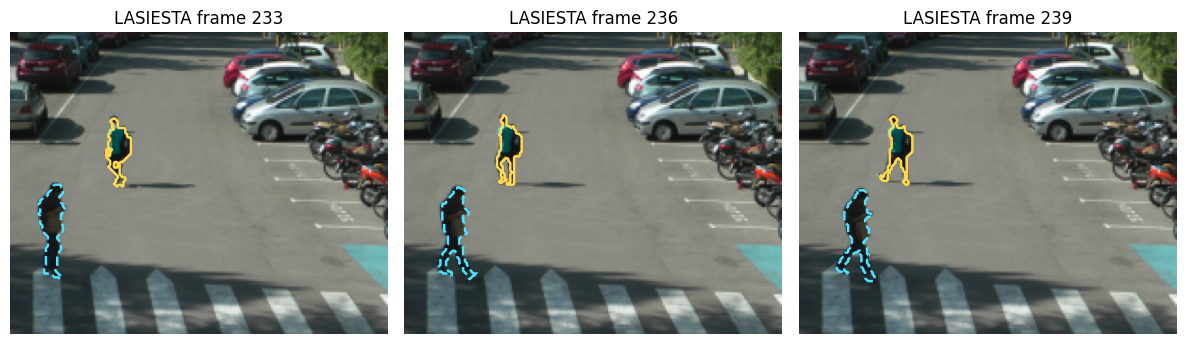

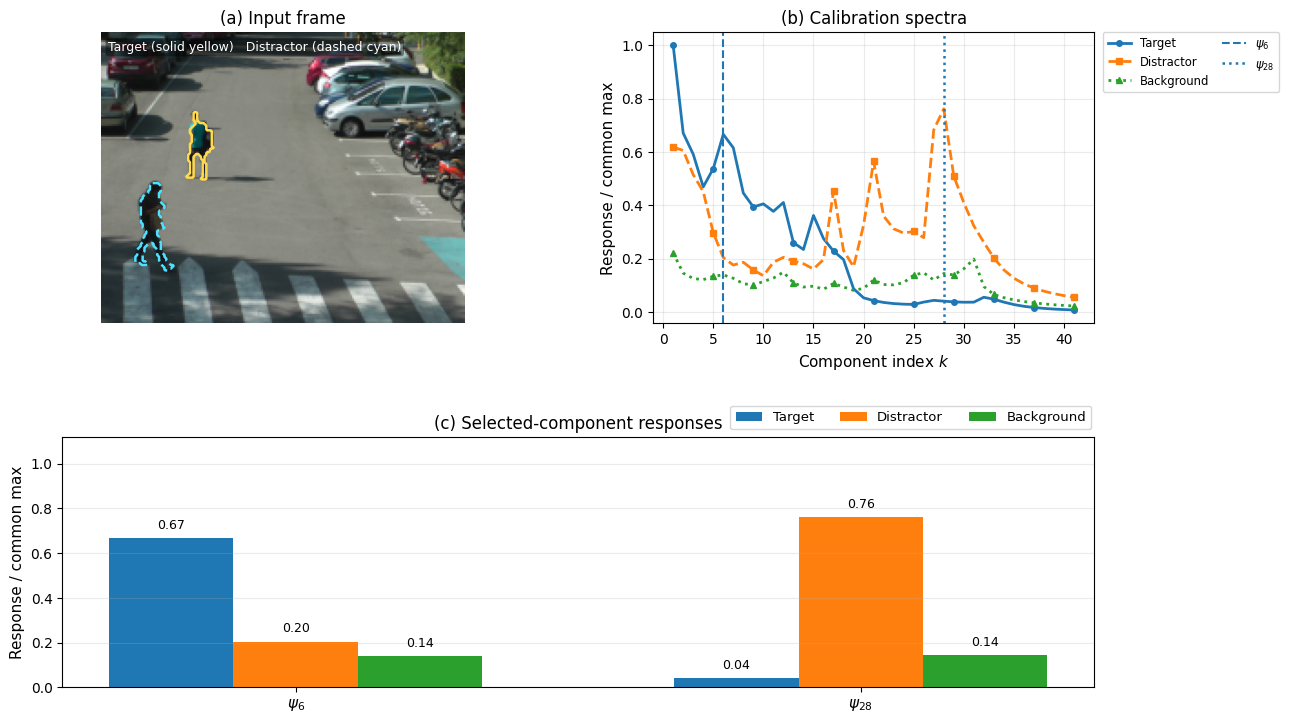

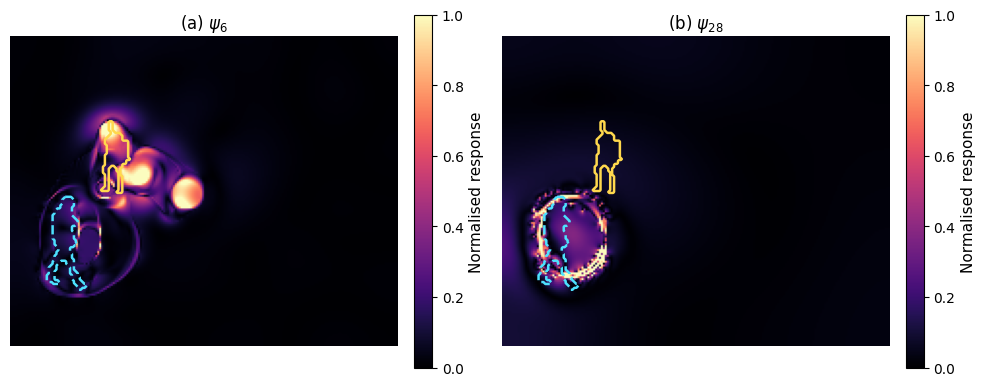

,sequence,frame_ids,ground_truth_layout,roi_definition,fixed_hs_alpha,target_relative_peak,distractor_relative_peak,target_peak_margin,distractor_peak_margin,target_peak_dominates_comparators,distractor_peak_dominates_comparators,heldout_pairs_evaluated,target_preference_preserved_pairs,distractor_preference_preserved_pairs,representative_visual_pair,interpretation
0,O_SU_02,233-239,native-colour-labels,native persistent LASIESTA labels 1 and 2,0.06,6,28,0.110453,0.147661,True,True,3,3,3,4->5,component-level regional preference: Target 3/...


,local_pair,source_pair,component_role,component_index,component_label,target_response,distractor_response,background_response,target_relative_to_component_max,distractor_relative_to_component_max,background_relative_to_component_max,dominant_region,calibration_preferred_region,preference_preserved
0,3->4,236->237,Target-relative,6,psi6,0.085686,0.055827,0.025801,1.000000,0.651528,0.301108,Target,Target,True
1,3->4,236->237,Distractor-relative,28,psi28,0.052360,0.185114,0.073108,0.282853,1.000000,0.394938,Distractor,Distractor,True
2,4->5,237->238,Target-relative,6,psi6,0.143509,0.036728,0.036603,1.000000,0.255931,0.255056,Target,Target,True
3,4->5,237->238,Distractor-relative,28,psi28,0.003840,0.015737,0.006632,0.244039,1.000000,0.421439,Distractor,Distractor,True
4,5->6,238->239,Target-relative,6,psi6,0.152295,0.078199,0.034133,1.000000,0.513470,0.224123,Target,Target,True
5,5->6,238->239,Distractor-relative,28,psi28,0.013356,0.257978,0.057773,0.051771,1.000000,0.223944,Distractor,Distractor,True


,response,region,mean_magnitude,relative_to_max_region
0,Target-relative component psi6,Target,0.143509,1.000000
1,Target-relative component psi6,Distractor,0.036728,0.255931
2,Target-relative component psi6,Background,0.036603,0.255056
3,Distractor-relative component psi28,Target,0.003840,0.244039
4,Distractor-relative component psi28,Distractor,0.015737,1.000000
5,Distractor-relative component psi28,Background,0.006632,0.421439


In [17]:
# LASIESTA O_SU_02 data and evaluation utilities
LASIESTA_DATASET_PATH = None
LASIESTA_AUTO_DOWNLOAD = True
LASIESTA_FORCE_REDOWNLOAD = False
LASIESTA_DOWNLOAD_TIMEOUT = 240
LASIESTA_SEQUENCE_ID = 'O_SU_02'
LASIESTA_NUM_FRAMES = 7
LASIESTA_RESIZE = (160, 200)  # (height, width)
LASIESTA_MIN_LABEL_AREA = 25
LASIESTA_GT_TOLERANCE = 12
LASIESTA_BACKGROUND_RING = 28
REAL_HS_ALPHA = HS_ALPHA  # fixed from the controlled synthetic calibration

# Official download locations. Alternative host/path forms are retained because
# the dataset site has used more than one URL layout.
LASIESTA_OFFICIAL_RGB_URLS = (
    'https://www.gti.ssr.upm.es/images/Data/Downloads/LASIESTA/O_SU_02.rar',
    'https://gti.ssr.upm.es/images/Data/Downloads/LASIESTA/O_SU_02.rar',
)
LASIESTA_OFFICIAL_GT_URLS = (
    'https://www.gti.ssr.upm.es/images/Data/Downloads/LASIESTA/O_SU_02_GT.rar',
    'https://gti.ssr.upm.es/images/Data/Downloads/LASIESTA/O_SU_02_GT.rar',
    'https://www.gti.ssr.upm.es/images/Data/Downloads/LASIESTA/O_SU_02_GT.zip',
    'https://gti.ssr.upm.es/images/Data/Downloads/LASIESTA/O_SU_02_GT.zip',
)

REAL_DATASET_NOTE = (
    'LASIESTA O_SU_02 real-world case study. RGB frames and colour ground-truth '
    'labels are downloaded automatically from the official LASIESTA host. '
    'Ground truth is used only to define ROI/evaluation masks and is never used '
    'as Horn--Schunck or Spectral-TV input.'
)

import subprocess
import urllib.error
import urllib.request
import zipfile
from urllib.parse import urlparse

LASIESTA_LABEL_COLOURS = {
    1: np.array([255, 0, 0], dtype=np.int16),
    2: np.array([0, 255, 0], dtype=np.int16),
    3: np.array([255, 255, 0], dtype=np.int16),
}
LASIESTA_IMAGE_SUFFIXES = {'.png', '.bmp', '.jpg', '.jpeg', '.tif', '.tiff'}


def _lasiesta_request(url):
    return urllib.request.Request(
        url,
        headers={
            'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) Chrome/124.0 spectral-motion-research/1.0',
            'Accept': '*/*',
            'Referer': 'https://www.gti.ssr.upm.es/data/LASIESTA',
        },
    )


def _archive_kind(prefix):
    if prefix.startswith(b'Rar!\x1a\x07'):
        return 'rar'
    if prefix.startswith(b'PK\x03\x04') or prefix.startswith(b'PK\x05\x06'):
        return 'zip'
    return None


def _download_archive(url, destination, force=False):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    if force:
        destination.unlink(missing_ok=True)
    if destination.exists() and destination.stat().st_size > 100_000:
        print(f'Using cached LASIESTA archive: {destination}')
        return destination

    print(f'Downloading LASIESTA asset:\n  {url}')
    temp = destination.with_suffix(destination.suffix + '.part')
    temp.unlink(missing_ok=True)
    try:
        with urllib.request.urlopen(_lasiesta_request(url), timeout=LASIESTA_DOWNLOAD_TIMEOUT) as response:
            total_header = response.headers.get('Content-Length')
            total = int(total_header) if total_header and total_header.isdigit() else 0
            downloaded = 0
            with temp.open('wb') as fh:
                while True:
                    chunk = response.read(1024 * 1024)
                    if not chunk:
                        break
                    fh.write(chunk)
                    downloaded += len(chunk)
                    if total:
                        print(
                            f'  {100 * downloaded / total:5.1f}% '
                            f'({downloaded / 1024**2:.1f}/{total / 1024**2:.1f} MB)',
                            end='\r',
                        )
        print()
    except urllib.error.HTTPError as exc:
        temp.unlink(missing_ok=True)
        raise RuntimeError(f'HTTP {exc.code} while downloading {url}') from exc
    except urllib.error.URLError as exc:
        temp.unlink(missing_ok=True)
        raise RuntimeError(f'Network error while downloading {url}: {exc.reason}') from exc

    if not temp.exists() or temp.stat().st_size < 100_000:
        temp.unlink(missing_ok=True)
        raise RuntimeError('Downloaded archive is unexpectedly small.')

    prefix = temp.read_bytes()[:16]
    kind = _archive_kind(prefix)
    if kind is None:
        temp.unlink(missing_ok=True)
        raise RuntimeError('The download did not return a recognised RAR/ZIP archive.')

    # Keep a suffix consistent with the actual payload, even if the server redirects.
    wanted_suffix = '.rar' if kind == 'rar' else '.zip'
    if destination.suffix.lower() != wanted_suffix:
        destination = destination.with_suffix(wanted_suffix)
    temp.replace(destination)
    return destination


def _install_unar_if_needed():
    """Install `unar` in Colab when needed.

    The official LASIESTA O_SU_02 archive uses a RAR compression method that
    some Colab 7-Zip builds cannot decode ("Unsupported Method"). This function
    installs `unar` when it is not already available.
    """
    if shutil.which('unar') is not None:
        return shutil.which('unar')

    print('Installing unar for LASIESTA RAR extraction...')
    commands = [
        ['apt-get', '-qq', 'update'],
        ['apt-get', '-qq', 'install', '-y', 'unar'],
    ]
    for command in commands:
        completed = subprocess.run(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
        )
        if completed.returncode != 0:
            raise RuntimeError(
                'Could not install unar automatically. Colab output:\n'
                + completed.stdout[-3000:]
                + '\nRun `!apt-get -qq update && apt-get -qq install -y unar` once and rerun this cell.'
            )

    executable = shutil.which('unar')
    if executable is None:
        raise RuntimeError(
            'unar installation finished but the executable is not on PATH. '
            'Run `!which unar` in Colab and rerun the cell.'
        )
    return executable


def _rar_extract_commands(archive, destination):
    """Return extractors in reliability order for the official LASIESTA RAR."""
    commands = []

    # Prefer unar because some Colab 7-Zip builds cannot decode this RAR archive.
    try:
        unar = _install_unar_if_needed()
        commands.append(('unar', [unar, '-q', '-f', '-o', str(destination), str(archive)]))
    except Exception as exc:
        print(f'unar preparation failed: {exc}')

    if shutil.which('unrar') is not None:
        commands.append(('unrar', ['unrar', 'x', '-o+', str(archive), str(destination)]))
    if shutil.which('7z') is not None:
        commands.append(('7z', ['7z', 'x', '-y', f'-o{destination}', str(archive)]))
    if shutil.which('bsdtar') is not None:
        commands.append(('bsdtar', ['bsdtar', '-xf', str(archive), '-C', str(destination)]))

    return commands


def _extract_archive_once(archive, destination, force=False):
    """Extract one downloaded LASIESTA archive with robust RAR fallbacks."""
    archive = Path(archive)
    destination = Path(destination)
    marker = destination / '.complete'

    if force and destination.exists():
        shutil.rmtree(destination)

    if marker.exists() and any(p.is_file() for p in destination.rglob('*')):
        return destination

    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)

    print(f'Extracting {archive.name} -> {destination}')
    prefix = archive.read_bytes()[:16]
    kind = _archive_kind(prefix)

    if kind == 'zip':
        with zipfile.ZipFile(archive, 'r') as zf:
            zf.extractall(destination)

    elif kind == 'rar':
        commands = _rar_extract_commands(archive, destination)
        if not commands:
            raise RuntimeError(
                'No compatible RAR extractor is available. In Colab run: '
                '`!apt-get -qq update && apt-get -qq install -y unar`, then rerun this cell.'
            )

        errors = []
        extracted = False
        for tool, command in commands:
            # Start each extraction attempt from a clean directory.
            if destination.exists():
                shutil.rmtree(destination)
            destination.mkdir(parents=True, exist_ok=True)

            print(f'Trying LASIESTA RAR extractor: {tool}')
            completed = subprocess.run(
                command,
                stdout=subprocess.PIPE,
                stderr=subprocess.STDOUT,
                text=True,
            )
            has_files = any(p.is_file() for p in destination.rglob('*'))
            if completed.returncode == 0 and has_files:
                print(f'RAR extracted successfully with {tool}.')
                extracted = True
                break

            output = completed.stdout[-4000:]
            errors.append(f'[{tool}] return code {completed.returncode}\n{output}')
            print(f'{tool} failed; trying the next extractor...')

        if not extracted:
            raise RuntimeError(
                'Every available RAR extractor failed for the LASIESTA archive.\n\n'
                + '\n\n'.join(errors)
                + '\n\nIn Google Colab, run `!apt-get -qq update && apt-get -qq install -y unar` '
                  'and rerun this real-world cell.'
            )

    else:
        raise RuntimeError(f'Unsupported archive payload: {archive}')

    if not any(p.is_file() for p in destination.rglob('*')):
        raise RuntimeError(f'Extraction produced no files: {archive}')

    marker.write_text('ok', encoding='utf-8')
    return destination

def _find_named_dir(root, name):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob('*') if p.is_dir()]
    exact = [p for p in candidates if p.name.lower() == name.lower()]
    return min(exact, key=lambda p: len(p.parts)) if exact else None


def _image_files_in_dir(folder):
    folder = Path(folder)
    return sorted([
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in LASIESTA_IMAGE_SUFFIXES
    ])


def _looks_like_lasiesta_colour_gt(folder):
    """Recognise LASIESTA colour-label images even if the folder name changed."""
    files = _image_files_in_dir(folder)
    if len(files) < LASIESTA_NUM_FRAMES:
        return False
    palette = np.array([
        [0, 0, 0], [255, 0, 0], [0, 255, 0], [255, 255, 0],
        [255, 255, 255], [128, 128, 128],
    ], dtype=np.int16)
    scores = []
    for path in files[:min(3, len(files))]:
        bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if bgr is None:
            continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.int16)
        # Sample sparsely for speed.
        sample = rgb[::4, ::4].reshape(-1, 3)
        delta = np.abs(sample[:, None, :] - palette[None, :, :]).max(axis=2)
        scores.append(float((delta.min(axis=1) <= LASIESTA_GT_TOLERANCE).mean()))
    return bool(scores and np.mean(scores) > 0.97)


def _find_dataset_layout(root, sequence_id='O_SU_02'):
    """Return (rgb_root, gt_root, layout) for native LASIESTA or legacy CDnet layout."""
    root = Path(root)
    if not root.exists():
        return None

    rgb = _find_named_dir(root, sequence_id)
    gt = _find_named_dir(root, f'{sequence_id}_GT')
    if rgb is not None and gt is not None:
        return rgb, gt, 'native-colour-labels'

    # Keep legacy local support if a previously extracted CDnet copy already exists.
    candidates = [root] + [p for p in root.rglob('*') if p.is_dir()]
    for candidate in candidates:
        input_dir = candidate / 'input'
        gt_dir = candidate / 'groundtruth'
        if input_dir.is_dir() and gt_dir.is_dir():
            return input_dir, gt_dir, 'cdnet-binary-foreground'

    # Official archives have changed layout before. If folder names are unfamiliar,
    # identify the colour-label directory from the official six-colour GT palette and
    # pair it with the largest non-GT image directory.
    image_dirs = []
    for candidate in candidates:
        try:
            count = len(_image_files_in_dir(candidate))
        except (PermissionError, OSError):
            continue
        if count >= LASIESTA_NUM_FRAMES:
            image_dirs.append((candidate, count))

    gt_candidates = [
        (folder, count) for folder, count in image_dirs
        if _looks_like_lasiesta_colour_gt(folder)
    ]
    if gt_candidates:
        gt_guess, gt_count = max(gt_candidates, key=lambda item: item[1])
        rgb_candidates = [
            (folder, count) for folder, count in image_dirs
            if folder != gt_guess and not _looks_like_lasiesta_colour_gt(folder)
        ]
        if rgb_candidates:
            # Prefer a similarly sized temporal sequence, then the largest folder.
            rgb_guess, _ = min(
                rgb_candidates,
                key=lambda item: (abs(item[1] - gt_count), -item[1]),
            )
            print(
                'Detected native LASIESTA RGB/GT by image content despite non-standard folder names:\n'
                f'  RGB: {rgb_guess}\n  GT:  {gt_guess}'
            )
            return rgb_guess, gt_guess, 'native-colour-labels'
    return None


def discover_lasiesta_roots(explicit_path=None, sequence_id='O_SU_02'):
    search_roots = []
    if explicit_path is not None:
        search_roots.append(Path(explicit_path).expanduser())
    search_roots.extend([
        Path.cwd(),
        Path('/content'),
        Path('/mnt/data'),
        CACHE_DIR / 'lasiesta_official_pair' / 'extracted',
        CACHE_DIR / 'lasiesta_cdnet_dataset' / 'extracted',
    ])

    checked = []
    seen = set()
    for candidate in search_roots:
        if not candidate.exists():
            continue
        candidate = candidate.resolve()
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        checked.append(candidate)
        layout = _find_dataset_layout(candidate, sequence_id)
        if layout is not None:
            return layout

    raise FileNotFoundError(
        'LASIESTA O_SU_02 RGB + GT were not found locally. Checked: '
        + ', '.join(map(str, checked))
    )


def _try_url_group(urls, destination_dir, stem, force=False):
    errors = []
    for index, url in enumerate(urls, start=1):
        suffix = Path(urlparse(url).path).suffix or '.rar'
        destination = destination_dir / f'{stem}_{index}{suffix}'
        try:
            return _download_archive(url, destination, force=force)
        except Exception as exc:
            errors.append(f'{url}: {type(exc).__name__}: {exc}')
            print(f'Candidate failed: {exc}')
    raise RuntimeError('\n'.join(errors))


def auto_download_lasiesta(sequence_id='O_SU_02', force=False):
    """Download official RGB and colour GT archives and validate the pair."""
    cache_root = CACHE_DIR / 'lasiesta_official_pair'
    download_dir = cache_root / 'downloads'
    extracted = cache_root / 'extracted'
    rgb_extract = extracted / 'rgb_asset'
    gt_extract = extracted / 'gt_asset'

    if force and cache_root.exists():
        shutil.rmtree(cache_root)

    layout = _find_dataset_layout(extracted, sequence_id)
    if layout is not None:
        print(f'Using cached official LASIESTA RGB + GT: {extracted}')
        return layout

    print('Downloading official LASIESTA RGB sequence...')
    rgb_archive = _try_url_group(
        LASIESTA_OFFICIAL_RGB_URLS,
        download_dir,
        'O_SU_02_RGB',
        force=force,
    )
    _extract_archive_once(rgb_archive, rgb_extract, force=force)

    # Some historical packages may already contain both folders.
    layout = _find_dataset_layout(extracted, sequence_id)
    if layout is not None:
        print('Official RGB archive already contains both RGB and GT.')
        return layout

    print('RGB is ready; downloading the companion LASIESTA colour GT archive...')
    gt_archive = _try_url_group(
        LASIESTA_OFFICIAL_GT_URLS,
        download_dir,
        'O_SU_02_GT',
        force=force,
    )
    _extract_archive_once(gt_archive, gt_extract, force=force)

    layout = _find_dataset_layout(extracted, sequence_id)
    if layout is None:
        # Print a concise inventory to make any future site-layout change obvious.
        folders = sorted({str(p.relative_to(extracted)) for p in extracted.rglob('*') if p.is_dir()})
        raise RuntimeError(
            'Both official archives were downloaded and extracted, but the expected '
            f'{sequence_id}/ and {sequence_id}_GT/ folders were not found.\n'
            'Extracted folders (first 60):\n  ' + '\n  '.join(folders[:60])
        )

    print('LASIESTA O_SU_02 official RGB + colour ground truth are ready.')
    return layout


def prepare_lasiesta_roots(explicit_path=None, sequence_id='O_SU_02'):
    try:
        return discover_lasiesta_roots(explicit_path, sequence_id)
    except FileNotFoundError:
        if not LASIESTA_AUTO_DOWNLOAD:
            raise
        print('No local LASIESTA O_SU_02 RGB + GT dataset found.')
        print('Attempting automatic download from the official LASIESTA host...')
        return auto_download_lasiesta(sequence_id, force=LASIESTA_FORCE_REDOWNLOAD)


def _numeric_index(path):
    matches = re.findall(r'(\d+)', Path(path).stem)
    return int(matches[-1]) if matches else None


def _indexed_images(folder):
    folder = Path(folder)
    mapping = {}
    for path in folder.iterdir():
        if path.is_file() and path.suffix.lower() in LASIESTA_IMAGE_SUFFIXES:
            idx = _numeric_index(path)
            if idx is not None:
                mapping[idx] = path
    return mapping


def aligned_lasiesta_files(rgb_root, gt_root):
    rgb_files = _indexed_images(rgb_root)
    gt_files = _indexed_images(gt_root)
    if not rgb_files:
        raise FileNotFoundError(f'No indexed RGB images found in {rgb_root}')
    if not gt_files:
        raise FileNotFoundError(f'No indexed ground-truth images found in {gt_root}')
    common = sorted(set(rgb_files) & set(gt_files))
    if len(common) < LASIESTA_NUM_FRAMES:
        raise ValueError(f'Only {len(common)} aligned RGB/GT frames were found.')
    return rgb_files, gt_files, common


def read_rgb_float(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f'Cannot read RGB frame: {path}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0


def read_gt_rgb(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f'Cannot read ground truth: {path}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def read_gt_gray(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f'Cannot read ground truth: {path}')
    return image


def label_mask_from_gt(gt_rgb, label, tolerance=12):
    colour = LASIESTA_LABEL_COLOURS[int(label)]
    diff = np.abs(gt_rgb.astype(np.int16) - colour[None, None, :])
    return np.max(diff, axis=-1) <= int(tolerance)


def choose_native_two_person_window(gt_files, common_ids, n_frames=7, min_area=25):
    common_set = set(common_ids)
    best = None
    for start in common_ids:
        ids = list(range(start, start + n_frames))
        if not all(i in common_set for i in ids):
            continue
        areas_1, areas_2 = [], []
        for frame_id in ids:
            gt = read_gt_rgb(gt_files[frame_id])
            areas_1.append(int(label_mask_from_gt(gt, 1, LASIESTA_GT_TOLERANCE).sum()))
            areas_2.append(int(label_mask_from_gt(gt, 2, LASIESTA_GT_TOLERANCE).sum()))
        if min(areas_1) < min_area or min(areas_2) < min_area:
            continue
        score = min(float(np.mean(areas_1)), float(np.mean(areas_2)))
        if best is None or score > best[0]:
            best = (score, ids)
    if best is None:
        raise RuntimeError('Could not find seven consecutive native LASIESTA frames containing labels 1 and 2.')
    return best[1]


@dataclass
class _FGComponent:
    mask: np.ndarray
    centroid: np.ndarray
    area: int


def _cdnet_foreground(gt_gray):
    # CDnet: 255 foreground; 170 is unknown/transition and is not needed for stable tracking.
    mask = (gt_gray == 255).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask.astype(bool)


def _components(mask, min_area=25):
    count, labels, stats, centroids = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
    out = []
    max_area = int(0.20 * mask.size)
    for label in range(1, count):
        area = int(stats[label, cv2.CC_STAT_AREA])
        if area < min_area or area > max_area:
            continue
        out.append(_FGComponent(
            mask=(labels == label),
            centroid=np.asarray(centroids[label], dtype=np.float32),
            area=area,
        ))
    return out


def _pair_assignment(previous_a, previous_b, candidates):
    best = None
    for i, j in itertools.permutations(range(len(candidates)), 2):
        a, b = candidates[i], candidates[j]
        da = float(np.linalg.norm(a.centroid - previous_a.centroid))
        db = float(np.linalg.norm(b.centroid - previous_b.centroid))
        area_penalty = abs(math.log((a.area + 1e-6) / (previous_a.area + 1e-6)))
        area_penalty += abs(math.log((b.area + 1e-6) / (previous_b.area + 1e-6)))
        cost = da + db + 8.0 * area_penalty
        if best is None or cost < best[0]:
            best = (cost, a, b, da, db)
    return best


def choose_cdnet_two_person_tracks(gt_files, common_ids, n_frames=7, min_area=25):
    """Find a stable 7-frame window with two disconnected moving components."""
    common_set = set(common_ids)
    component_cache = {}

    def comps(frame_id):
        if frame_id not in component_cache:
            component_cache[frame_id] = _components(
                _cdnet_foreground(read_gt_gray(gt_files[frame_id])),
                min_area=min_area,
            )
        return component_cache[frame_id]

    best = None
    for start in common_ids:
        ids = list(range(start, start + n_frames))
        if not all(i in common_set for i in ids):
            continue
        first = sorted(comps(ids[0]), key=lambda c: c.area, reverse=True)[:6]
        if len(first) < 2:
            continue

        for first_a, first_b in itertools.combinations(first, 2):
            track_a = [first_a]
            track_b = [first_b]
            valid = True
            for frame_id in ids[1:]:
                candidates = comps(frame_id)
                if len(candidates) < 2:
                    valid = False
                    break
                assignment = _pair_assignment(track_a[-1], track_b[-1], candidates)
                if assignment is None:
                    valid = False
                    break
                _, next_a, next_b, da, db = assignment
                # Generous threshold: prevents switching to distant unrelated foreground.
                if max(da, db) > 60.0:
                    valid = False
                    break
                track_a.append(next_a)
                track_b.append(next_b)
            if not valid:
                continue

            areas_a = np.asarray([c.area for c in track_a], dtype=float)
            areas_b = np.asarray([c.area for c in track_b], dtype=float)
            separation = np.asarray([
                np.linalg.norm(a.centroid - b.centroid)
                for a, b in zip(track_a, track_b)
            ])
            if separation.min() < 8.0:
                continue
            score = min(areas_a.mean(), areas_b.mean()) + 0.20 * separation.mean()
            if best is None or score > best[0]:
                best = (score, ids, track_a, track_b)

    if best is None:
        raise RuntimeError(
            'Could not find seven consecutive CDnet frames with two stable disconnected pedestrians.'
        )

    _, ids, track_a, track_b = best
    # Define the faster track over the calibration interval as Target. This definition is
    # independent of the spectral result and uses GT only for ROI naming/tracking.
    def calibration_speed(track):
        pts = np.asarray([c.centroid for c in track[:3]])
        return float(np.linalg.norm(np.diff(pts, axis=0), axis=1).mean())

    speed_a = calibration_speed(track_a)
    speed_b = calibration_speed(track_b)
    if speed_b > speed_a:
        track_a, track_b = track_b, track_a
        speed_a, speed_b = speed_b, speed_a
    print(f'CDnet ROI tracks: Target mean calibration displacement={speed_a:.2f} px/frame; '
          f'Distractor={speed_b:.2f} px/frame')
    return ids, [c.mask for c in track_a], [c.mask for c in track_b]


def resize_frame_and_mask(frame, mask, shape_hw):
    h, w = map(int, shape_hw)
    resized_frame = cv2.resize(frame, (w, h), interpolation=cv2.INTER_AREA)
    resized_mask = cv2.resize(mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST).astype(bool)
    return resized_frame.astype(np.float32), resized_mask


def local_background_mask(target_mask, distractor_mask, radius=28):
    union = target_mask | distractor_mask
    k = 2 * int(radius) + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    outer = cv2.dilate(union.astype(np.uint8), kernel) > 0
    ring = outer & ~union
    return ring


def regional_component_magnitude_profile(decomposition, mask):
    component_magnitude = np.linalg.norm(decomposition['components'], axis=-1)
    return component_magnitude[:, mask].mean(axis=1)


def calibration_realworld_profiles(decompositions, target_masks, distractor_masks, background_masks, pairs=CALIBRATION_PAIRS):
    target, distractor, background = [], [], []
    for pair in pairs:
        target.append(regional_component_magnitude_profile(decompositions[pair], target_masks[pair]))
        distractor.append(regional_component_magnitude_profile(decompositions[pair], distractor_masks[pair]))
        background.append(regional_component_magnitude_profile(decompositions[pair], background_masks[pair]))
    return np.mean(target, axis=0), np.mean(distractor, axis=0), np.mean(background, axis=0)


def discriminative_peak(profile, other_a, other_b):
    margin = np.asarray(profile) - np.maximum(np.asarray(other_a), np.asarray(other_b))
    return int(np.argmax(margin)), margin


def _contour_real_rois(ax, target_mask, distractor_mask):
    ax.contour(target_mask.astype(float), levels=[0.5], colors=['#ffd84d'], linewidths=1.8, linestyles='-')
    ax.contour(distractor_mask.astype(float), levels=[0.5], colors=['#4de1ff'], linewidths=1.8, linestyles='--')


def realworld_response_table(response_map, target_mask, distractor_mask, background_mask, name):
    values = {
        'Target': float(response_map[target_mask].mean()),
        'Distractor': float(response_map[distractor_mask].mean()),
        'Background': float(response_map[background_mask].mean()),
    }
    scale = max(values.values()) + 1e-12
    return pd.DataFrame([
        {'response': name, 'region': region, 'mean_magnitude': value, 'relative_to_max_region': value / scale}
        for region, value in values.items()
    ])


def lasiesta_all_heldout_component_table(
    decompositions,
    target_masks,
    distractor_masks,
    background_masks,
    frame_ids,
    target_peak,
    distractor_peak,
    pairs=HELDOUT_PAIRS,
):
    """Evaluate the frozen calibration-selected components on every held-out pair."""
    rows = []
    selected = [
        ('Target-relative', target_peak, 'Target'),
        ('Distractor-relative', distractor_peak, 'Distractor'),
    ]

    for pair in pairs:
        if pair not in decompositions:
            raise KeyError(f'Missing LASIESTA decomposition for held-out pair {pair}->{pair + 1}.')

        for role, component_index, expected_region in selected:
            response_map = np.linalg.norm(
                decompositions[pair]['components'][component_index],
                axis=-1,
            )
            values = {
                'Target': float(response_map[target_masks[pair]].mean()),
                'Distractor': float(response_map[distractor_masks[pair]].mean()),
                'Background': float(response_map[background_masks[pair]].mean()),
            }
            scale = max(values.values()) + 1e-12
            dominant_region = max(values, key=values.get)

            rows.append({
                'local_pair': f'{pair}->{pair + 1}',
                'source_pair': f'{frame_ids[pair]}->{frame_ids[pair + 1]}',
                'component_role': role,
                'component_index': component_index + 1,
                'component_label': f'psi{component_index + 1}',
                'target_response': values['Target'],
                'distractor_response': values['Distractor'],
                'background_response': values['Background'],
                'target_relative_to_component_max': values['Target'] / scale,
                'distractor_relative_to_component_max': values['Distractor'] / scale,
                'background_relative_to_component_max': values['Background'] / scale,
                'dominant_region': dominant_region,
                'calibration_preferred_region': expected_region,
                'preference_preserved': dominant_region == expected_region,
            })

    return pd.DataFrame(rows)


def lasiesta_all_heldout_long_table(compact_table):
    """Convert the compact LASIESTA table to one row per region."""
    rows = []
    region_specs = [
        ('Target', 'target_response', 'target_relative_to_component_max'),
        ('Distractor', 'distractor_response', 'distractor_relative_to_component_max'),
        ('Background', 'background_response', 'background_relative_to_component_max'),
    ]
    for _, row in compact_table.iterrows():
        for region, raw_col, rel_col in region_specs:
            rows.append({
                'local_pair': row['local_pair'],
                'source_pair': row['source_pair'],
                'component_role': row['component_role'],
                'component_index': int(row['component_index']),
                'component_label': row['component_label'],
                'region': region,
                'mean_magnitude': float(row[raw_col]),
                'relative_to_max_region': float(row[rel_col]),
                'dominant_region': row['dominant_region'],
                'calibration_preferred_region': row['calibration_preferred_region'],
                'preference_preserved': bool(row['preference_preserved']),
            })
    return pd.DataFrame(rows)


def plot_lasiesta_case_study(frames, decompositions, target_masks, distractor_masks, background_masks,
                             target_profile, distractor_profile, background_profile,
                             target_peak, distractor_peak, representative_pair, path, diagnostics_path):
    """Create the case-study figure and held-out component heatmaps."""
    dec = decompositions[representative_pair]
    target_field = dec['components'][target_peak]
    distractor_field = dec['components'][distractor_peak]

    target_map_raw = np.linalg.norm(target_field, axis=-1)
    distractor_map_raw = np.linalg.norm(distractor_field, axis=-1)

    target_table = realworld_response_table(
        target_map_raw,
        target_masks[representative_pair],
        distractor_masks[representative_pair],
        background_masks[representative_pair],
        f'Target-relative component psi{target_peak+1}'
    )
    distractor_table = realworld_response_table(
        distractor_map_raw,
        target_masks[representative_pair],
        distractor_masks[representative_pair],
        background_masks[representative_pair],
        f'Distractor-relative component psi{distractor_peak+1}'
    )
    response_table = pd.concat([target_table, distractor_table], ignore_index=True)

    fig = plt.figure(figsize=(13.4, 7.8))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.86], hspace=0.42, wspace=0.34)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[1, :])

    ax0.imshow(np.clip(frames[representative_pair], 0.0, 1.0))
    _contour_real_rois(ax0, target_masks[representative_pair], distractor_masks[representative_pair])
    ax0.set_title('(a) Input frame', fontsize=12)
    ax0.text(0.02, 0.97, 'Target (solid yellow)   Distractor (dashed cyan)', transform=ax0.transAxes,
             fontsize=9.0, va='top', ha='left', color='white',
             bbox=dict(boxstyle='round,pad=0.20', facecolor='black', alpha=0.42, edgecolor='none'))
    ax0.axis('off')

    k = np.arange(1, len(target_profile) + 1)
    common_max = max(float(target_profile.max()), float(distractor_profile.max()), float(background_profile.max()), 1e-12)
    target_norm = target_profile / common_max
    distractor_norm = distractor_profile / common_max
    background_norm = background_profile / common_max

    ax1.plot(k, target_norm, label='Target', linewidth=2.0, linestyle='-', marker='o', markevery=4, markersize=4)
    ax1.plot(k, distractor_norm, label='Distractor', linewidth=2.0, linestyle='--', marker='s', markevery=4, markersize=4)
    ax1.plot(k, background_norm, label='Background', linewidth=2.0, linestyle=':', marker='^', markevery=4, markersize=4)
    ax1.axvline(target_peak + 1, linestyle='--', linewidth=1.5, label=fr'$\psi_{{{target_peak+1}}}$')
    ax1.axvline(distractor_peak + 1, linestyle=':', linewidth=1.8, label=fr'$\psi_{{{distractor_peak+1}}}$')
    ax1.set_xlabel('Component index $k$')
    ax1.set_ylabel('Response / common max')
    ax1.set_title('(b) Calibration spectra', fontsize=12)
    ax1.grid(alpha=0.25)
    ax1.legend(fontsize=8.4, ncol=2, frameon=True, loc='upper left',
               bbox_to_anchor=(1.02, 1.00), borderaxespad=0.0,
               columnspacing=1.1, handlelength=2.0)

    region_order = ['Target', 'Distractor', 'Background']
    calibration_values = {
        fr'$\psi_{{{target_peak+1}}}$': [target_norm[target_peak], distractor_norm[target_peak], background_norm[target_peak]],
        fr'$\psi_{{{distractor_peak+1}}}$': [target_norm[distractor_peak], distractor_norm[distractor_peak], background_norm[distractor_peak]],
    }
    group_labels = list(calibration_values.keys())
    x = np.arange(len(group_labels))
    width = 0.22
    offsets = [-width, 0.0, width]
    for region_idx, (region, offset) in enumerate(zip(region_order, offsets)):
        vals = [calibration_values[group][region_idx] for group in group_labels]
        ax2.bar(x + offset, vals, width=width, label=region)
        for j, val in enumerate(vals):
            ax2.text(x[j] + offset, val + 0.03, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    ax2.set_xticks(x)
    ax2.set_xticklabels(group_labels, fontsize=11)
    ax2.set_ylim(0, 1.12)
    ax2.set_ylabel('Response / common max')
    ax2.set_title('(c) Selected-component responses', fontsize=12)
    ax2.grid(axis='y', alpha=0.25)
    ax2.legend(ncol=3, fontsize=9.5, frameon=True, loc='lower right',
               bbox_to_anchor=(1.0, 1.02), borderaxespad=0.2)

    fig.subplots_adjust(left=0.07, right=0.84, top=0.95, bottom=0.11)
    save_show(fig, path, dpi=200)

    target_scale = max(float(np.percentile(target_map_raw, 99.5)), 1e-8)
    distractor_scale = max(float(np.percentile(distractor_map_raw, 99.5)), 1e-8)
    target_map = np.clip(target_map_raw / target_scale, 0.0, 1.0)
    distractor_map = np.clip(distractor_map_raw / distractor_scale, 0.0, 1.0)

    fig2, axes = plt.subplots(1, 2, figsize=(10.0, 4.0))
    im0 = axes[0].imshow(target_map, cmap='magma', vmin=0, vmax=1)
    _contour_real_rois(axes[0], target_masks[representative_pair], distractor_masks[representative_pair])
    axes[0].set_title(fr'(a) $\psi_{{{target_peak+1}}}$')
    axes[0].axis('off')
    fig2.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='Normalised response')

    im1 = axes[1].imshow(distractor_map, cmap='magma', vmin=0, vmax=1)
    _contour_real_rois(axes[1], target_masks[representative_pair], distractor_masks[representative_pair])
    axes[1].set_title(fr'(b) $\psi_{{{distractor_peak+1}}}$')
    axes[1].axis('off')
    fig2.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Normalised response')

    fig2.tight_layout()
    save_show(fig2, diagnostics_path, dpi=200)

    return response_table


def run_lasiesta_case_study(dataset_path=None):
    rgb_root, gt_root, gt_layout = prepare_lasiesta_roots(dataset_path, LASIESTA_SEQUENCE_ID)
    print(f'Real-world ground-truth layout: {gt_layout}')
    rgb_files, gt_files, common_ids = aligned_lasiesta_files(rgb_root, gt_root)

    # Native LASIESTA keeps persistent object colours. CDnet supplies binary foreground,
    # so two disconnected components are tracked automatically instead.
    if gt_layout == 'native-colour-labels':
        frame_ids = choose_native_two_person_window(
            gt_files, common_ids, n_frames=LASIESTA_NUM_FRAMES, min_area=LASIESTA_MIN_LABEL_AREA
        )
        target_masks_original = []
        distractor_masks_original = []
        for frame_id in frame_ids:
            gt = read_gt_rgb(gt_files[frame_id])
            target_masks_original.append(label_mask_from_gt(gt, 1, LASIESTA_GT_TOLERANCE))
            distractor_masks_original.append(label_mask_from_gt(gt, 2, LASIESTA_GT_TOLERANCE))
        roi_definition = 'native persistent LASIESTA labels 1 and 2'
    else:
        frame_ids, target_masks_original, distractor_masks_original = choose_cdnet_two_person_tracks(
            gt_files, common_ids, n_frames=LASIESTA_NUM_FRAMES, min_area=LASIESTA_MIN_LABEL_AREA
        )
        roi_definition = 'two automatically tracked disconnected CDnet foreground components; faster calibration track named Target'

    print('Selected real-world frame IDs:', frame_ids)

    frames, target_masks, distractor_masks, background_masks = [], [], [], []
    for frame_id, mt0, md0 in zip(frame_ids, target_masks_original, distractor_masks_original):
        frame0 = read_rgb_float(rgb_files[frame_id])
        frame, mt = resize_frame_and_mask(frame0, mt0, LASIESTA_RESIZE)
        _, md = resize_frame_and_mask(frame0, md0, LASIESTA_RESIZE)
        mb = local_background_mask(mt, md, LASIESTA_BACKGROUND_RING)
        frames.append(frame)
        target_masks.append(mt)
        distractor_masks.append(md)
        background_masks.append(mb)

    frames = np.stack(frames)

    # Multi-frame context figure before the spectral response is inspected.
    context_indices = [0, 3, 6]
    fig_context, axes_context = plt.subplots(1, 3, figsize=(12.0, 4.0))
    for ax, local_idx in zip(axes_context, context_indices):
        ax.imshow(np.clip(frames[local_idx], 0.0, 1.0))
        _contour_real_rois(ax, target_masks[local_idx], distractor_masks[local_idx])
        ax.set_title(f'LASIESTA frame {frame_ids[local_idx]}')
        ax.axis('off')
    fig_context.tight_layout()
    save_show(fig_context, FIG_DIR / 'figure_11a_lasiesta_input_frames.png', dpi=200)

    flows = {}
    decompositions = {}
    for pair in range(LASIESTA_NUM_FRAMES - 1):
        flow = horn_schunck_pyramid(
            frames[pair], frames[pair + 1],
            alpha=REAL_HS_ALPHA, levels=HS_LEVELS, warps=HS_WARPS,
            iters_per_warp=HS_ITERS_PER_WARP,
        )
        flows[pair] = flow
        if pair in MAIN_PAIRS:
            decompositions[pair] = tv_spectral_decomposition(
                flow, dt=DT, n_steps=N_TV_STEPS, tv_iters=TV_ITERS_MAIN,
            )

    target_profile, distractor_profile, background_profile = calibration_realworld_profiles(
        decompositions, target_masks, distractor_masks, background_masks, CALIBRATION_PAIRS
    )

    target_peak, target_margin = discriminative_peak(
        target_profile, distractor_profile, background_profile
    )
    distractor_peak, distractor_margin = discriminative_peak(
        distractor_profile, target_profile, background_profile
    )

    # The middle held-out pair remains a representative visualisation only.
    representative_pair = HELDOUT_PAIRS[1]
    representative_response_table = plot_lasiesta_case_study(
        frames, decompositions, target_masks, distractor_masks, background_masks,
        target_profile, distractor_profile, background_profile,
        target_peak, distractor_peak, representative_pair,
        FIG_DIR / 'figure_11_lasiesta_realworld_case_study.png',
        FIG_DIR / 'figure_11s_lasiesta_realworld_diagnostics.png',
    )
    representative_response_table.to_csv(
        TABLE_DIR / 'lasiesta_representative_spatial_response.csv',
        index=False,
    )

    # Same frozen components, now quantified on all three held-out transitions.
    heldout_component_table = lasiesta_all_heldout_component_table(
        decompositions,
        target_masks,
        distractor_masks,
        background_masks,
        frame_ids,
        target_peak,
        distractor_peak,
        pairs=HELDOUT_PAIRS,
    )
    heldout_component_long = lasiesta_all_heldout_long_table(heldout_component_table)

    heldout_component_table.to_csv(
        TABLE_DIR / 'lasiesta_heldout_component_responses.csv',
        index=False,
    )
    heldout_component_long.to_csv(
        TABLE_DIR / 'lasiesta_heldout_component_responses_long.csv',
        index=False,
    )

    target_is_positive = bool(target_margin[target_peak] > 0)
    distractor_is_positive = bool(distractor_margin[distractor_peak] > 0)

    target_heldout = heldout_component_table[
        heldout_component_table['component_role'] == 'Target-relative'
    ]
    distractor_heldout = heldout_component_table[
        heldout_component_table['component_role'] == 'Distractor-relative'
    ]
    target_preserved_count = int(target_heldout['preference_preserved'].sum())
    distractor_preserved_count = int(distractor_heldout['preference_preserved'].sum())
    n_heldout = len(HELDOUT_PAIRS)

    summary = pd.DataFrame([{
        'sequence': LASIESTA_SEQUENCE_ID,
        'frame_ids': f'{frame_ids[0]}-{frame_ids[-1]}',
        'ground_truth_layout': gt_layout,
        'roi_definition': roi_definition,
        'fixed_hs_alpha': REAL_HS_ALPHA,
        'target_relative_peak': target_peak + 1,
        'distractor_relative_peak': distractor_peak + 1,
        'target_peak_margin': float(target_margin[target_peak]),
        'distractor_peak_margin': float(distractor_margin[distractor_peak]),
        'target_peak_dominates_comparators': target_is_positive,
        'distractor_peak_dominates_comparators': distractor_is_positive,
        'heldout_pairs_evaluated': n_heldout,
        'target_preference_preserved_pairs': target_preserved_count,
        'distractor_preference_preserved_pairs': distractor_preserved_count,
        'representative_visual_pair': f'{representative_pair}->{representative_pair+1}',
        'interpretation': (
            f'component-level regional preference: Target {target_preserved_count}/{n_heldout} '
            f'held-out pairs; Distractor {distractor_preserved_count}/{n_heldout} held-out pairs'
        ),
    }])
    summary.to_csv(TABLE_DIR / 'lasiesta_realworld_summary.csv', index=False)

    display(summary)
    display(heldout_component_table)
    display(representative_response_table)

    return {
        'frames': frames,
        'frame_ids': frame_ids,
        'flows': flows,
        'decompositions': decompositions,
        'target_masks': target_masks,
        'distractor_masks': distractor_masks,
        'background_masks': background_masks,
        'target_profile': target_profile,
        'distractor_profile': distractor_profile,
        'background_profile': background_profile,
        'target_peak': target_peak,
        'distractor_peak': distractor_peak,
        'summary': summary,
        'heldout_component_table': heldout_component_table,
        'heldout_component_long': heldout_component_long,
        'representative_response_table': representative_response_table,
        # Backwards-compatible alias used by older reporting code.
        'response_table': representative_response_table,
    }


if RUN_REAL_WORLD_CASE_STUDY:
    try:
        real_world_result = run_lasiesta_case_study(LASIESTA_DATASET_PATH)
    except Exception as exc:
        print('LASIESTA real-world case study failed:')
        print(exc)
        print('Check the LASIESTA dataset path or download availability, then rerun this cell.')
else:
    print('LASIESTA real-world case study is disabled. Set RUN_REAL_WORLD_CASE_STUDY = True to run it.')


## 14. Result summary

The controlled results are reported in four forms:

1. calibration spectra and the selected Target-dominant interval;
2. retained mean directional motion on all three held-out pairs;
3. complementary full-vector endpoint change for the Target, Distractor, and background;
4. flow and trajectory visualisations using the same frozen interval.

Exact flow provides the reference condition without image-based motion-estimation error. The Horn--Schunck condition uses the rendered RGB frames and the calibrated value of \(\alpha\).

For LASIESTA, calibration still selects one Target-relative and one Distractor-relative component. The representative figure uses the middle held-out pair for visualisation, while the quantitative table reports the frozen components on all three held-out transitions. Each row includes the original regional component magnitudes, normalisation relative to the strongest region for that component and pair, and whether the calibration-time preferred region remains dominant.


In [18]:
# Held-out summary used for the main controlled-results table.
summary_rows = []
for method in ['Exact flow', 'Horn-Schunck']:
    for gain in [0.0, 2.0]:
        s = metrics[(metrics['method'] == method) & (metrics['gain'] == gain)]
        summary_rows.append({
            'method': method,
            'edit': 'suppression' if gain == 0 else 'amplification',

            # Primary retained mean directional motion.
            'target_retained_mean_pct': 100 * s['target_retained'].mean(),
            'target_retained_std_pct': 100 * s['target_retained'].std(ddof=1),
            'distractor_retained_mean_pct': 100 * s['distractor_retained'].mean(),
            'distractor_retained_std_pct': 100 * s['distractor_retained'].std(ddof=1),

            # Complementary full-vector changes.
            'target_relative_endpoint_change_mean_pct': 100 * s['target_relative_endpoint_change'].mean(),
            'target_relative_endpoint_change_std_pct': 100 * s['target_relative_endpoint_change'].std(ddof=1),
            'distractor_relative_endpoint_change_mean_pct': 100 * s['distractor_relative_endpoint_change'].mean(),
            'distractor_relative_endpoint_change_std_pct': 100 * s['distractor_relative_endpoint_change'].std(ddof=1),
            'background_endpoint_change_mean_px_per_frame': s['background_endpoint_change_px_per_frame'].mean(),
            'background_endpoint_change_std_px_per_frame': s['background_endpoint_change_px_per_frame'].std(ddof=1),
        })

thesis_summary = pd.DataFrame(summary_rows)
thesis_summary.to_csv(TABLE_DIR / 'thesis_main_result_summary.csv', index=False)
display(thesis_summary)


,method,edit,target_retained_mean_pct,target_retained_std_pct,distractor_retained_mean_pct,distractor_retained_std_pct,target_relative_endpoint_change_mean_pct,target_relative_endpoint_change_std_pct,distractor_relative_endpoint_change_mean_pct,distractor_relative_endpoint_change_std_pct,background_endpoint_change_mean_px_per_frame,background_endpoint_change_std_px_per_frame
0,Exact flow,suppression,16.238801,0.127238,99.923533,0.262895,83.959447,0.106862,0.605948,0.039353,0.100161,0.000324
1,Exact flow,amplification,183.761164,0.127227,100.076461,0.262889,83.959447,0.106862,0.605948,0.039353,0.100161,0.000324
2,Horn-Schunck,suppression,16.151963,2.534051,103.208625,0.712241,82.952862,2.272355,3.346723,0.782282,0.168698,0.013125
3,Horn-Schunck,amplification,183.847984,2.534024,96.791359,0.712247,82.952868,2.272351,3.346723,0.782282,0.168698,0.013125


## 15. Output files

The notebook writes the controlled input sequence, calibration figures, spectral analysis figures, held-out editing figures, trajectory visualisations, videos, and CSV tables to `spectral_motion_dissertation_outputs/`.

The controlled tables now include the full-vector endpoint-change metrics used to complement retained directional motion.

The LASIESTA run additionally saves the calibration/component figure, representative held-out component heatmaps, a compact all-held-out response table, and the corresponding long-form regional response table.


In [19]:
manifest = {
    'seed': SEED,
    'device': DEVICE,
    'dt': DT,
    'n_tv_steps': N_TV_STEPS,
    'tv_iters_per_step': TV_ITERS_MAIN,
    'capture_goal': CAPTURE_GOAL,
    'distractor_limit': DISTRACTOR_LIMIT,
    'horn_schunck_alpha': HS_ALPHA,
    'horn_schunck_levels': HS_LEVELS,
    'horn_schunck_warps': HS_WARPS,
    'horn_schunck_iterations_per_warp': HS_ITERS_PER_WARP,
    'calibration_pairs': CALIBRATION_PAIRS,
    'buffer_pair': BUFFER_PAIR,
    'heldout_pairs': HELDOUT_PAIRS,
    'controlled_full_vector_endpoint_change_enabled': True,
    'real_world_case_study_enabled': RUN_REAL_WORLD_CASE_STUDY,
    'real_world_sequence': LASIESTA_SEQUENCE_ID,
    'real_world_all_heldout_pairs_evaluated': True,
}
(OUTPUT_ROOT / 'run_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')

summary_text = [
    '# Spectral Motion Experiment Summary',
    '',
    '## Calibration-selected bands',
    band_table.to_markdown(index=False),
    '',
    '## Held-out motion editing',
    thesis_summary.to_markdown(index=False),
]

if RUN_REAL_WORLD_CASE_STUDY and 'real_world_result' in globals():
    summary_text.extend([
        '',
        '## LASIESTA held-out component responses',
        real_world_result['heldout_component_table'].to_markdown(index=False),
    ])

(OUTPUT_ROOT / 'RESULTS_SUMMARY.md').write_text('\n'.join(summary_text), encoding='utf-8')

archive = shutil.make_archive(str(OUTPUT_ROOT), 'zip', root_dir=OUTPUT_ROOT)
print(f'Output archive: {archive}')
print(f'Figures: {len(list(FIG_DIR.glob("*.png")))}')
print(f'Tables: {len(list(TABLE_DIR.glob("*.csv")))}')
print(f'Videos: {len(list(VIDEO_DIR.glob("*.mp4")))}')


Output archive: /content/spectral_motion_dissertation_outputs.zip
Figures: 14
Tables: 11
Videos: 5
